# Cyprus Community Bank: Loan Default Prediction

**DSC550 Group Project**

**Team members:** *Alexandros Panayi, Maria Michaelidou, Thanasis Kalos*

---

## 0. Setup and Imports

!pip install matplotlib
!pip install scikit-learn
!pip install seaborn


!pip install imbalanced-learn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score
)

# Optional: SMOTE for imbalanced data
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False
    print("imbalanced-learn not installed. Install with: pip install imbalanced-learn")

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

# Plot settings
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")


## 1. Load Data and Exploratory Data Analysis

Start by loading the dataset, checking its shape and types, and understanding the class distribution. Key questions to answer:
- What is the default rate? What does this tell you about class imbalance?
- Which features are most correlated with default?
- Are there any patterns by loan purpose?

In [2]:
df = pd.read_csv('cyprus_bank_loans.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nDefault rate: {df['default'].mean():.2%} ({df['default'].sum()} out of {len(df)})")
df.head()

Dataset shape: (10000, 13)

Default rate: 3.09% (309 out of 10000)


,age,years_employed,annual_income,credit_score,debt_to_income_ratio,num_existing_loans,previous_defaults,loan_amount,loan_term_months,loan_purpose,avg_monthly_balance,months_as_customer,default
0,30,5,28500.0,578,0.20,1,0,10000.0,12,personal,1756.75,90,0
1,29,1,18500.0,484,0.22,0,0,13000.0,24,debt_consolidation,499.62,66,0
2,45,1,20800.0,555,0.13,0,0,5000.0,12,personal,665.56,80,0
3,57,18,52000.0,697,0.47,3,0,16500.0,36,personal,799.61,270,0
4,48,25,52200.0,443,0.38,2,0,5000.0,12,personal,1265.13,87,0


In [3]:
# Explore the data
print("=== Basic Info ===")
df.info()
print("\n=== Descriptive Statistics ===")
df.describe().round(2)
#################################

=== Basic Info ===
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   10000 non-null  int64  
 1   years_employed        10000 non-null  int64  
 2   annual_income         10000 non-null  float64
 3   credit_score          10000 non-null  int64  
 4   debt_to_income_ratio  10000 non-null  float64
 5   num_existing_loans    10000 non-null  int64  
 6   previous_defaults     10000 non-null  int64  
 7   loan_amount           10000 non-null  float64
 8   loan_term_months      10000 non-null  int64  
 9   loan_purpose          10000 non-null  str    
 10  avg_monthly_balance   10000 non-null  float64
 11  months_as_customer    10000 non-null  int64  
 12  default               10000 non-null  int64  
dtypes: float64(4), int64(8), str(1)
memory usage: 1015.8 KB

=== Descriptive Statistics ===


,age,years_employed,annual_income,credit_score,debt_to_income_ratio,num_existing_loans,previous_defaults,loan_amount,loan_term_months,avg_monthly_balance,months_as_customer,default
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,40.53,8.99,32924.83,518.58,0.28,1.22,0.23,12442.95,31.92,881.12,74.83,0.03
std,9.89,6.31,15461.76,72.40,0.12,1.14,0.46,7147.01,16.33,636.93,48.15,0.17
min,21.00,0.00,15000.00,300.00,0.01,0.00,0.00,5000.00,12.00,100.00,1.00,0.00
25%,33.00,4.00,21700.00,469.00,0.19,0.00,0.00,5500.00,12.00,435.39,38.00,0.00
50%,40.00,7.00,29500.00,518.00,0.27,1.00,0.00,11000.00,24.00,726.27,66.00,0.00
75%,48.00,12.00,40200.00,567.00,0.35,2.00,0.00,17000.00,48.00,1154.80,103.00,0.00
max,69.00,42.00,159200.00,819.00,0.80,7.00,3.00,50000.00,60.00,6835.45,360.00,1.00


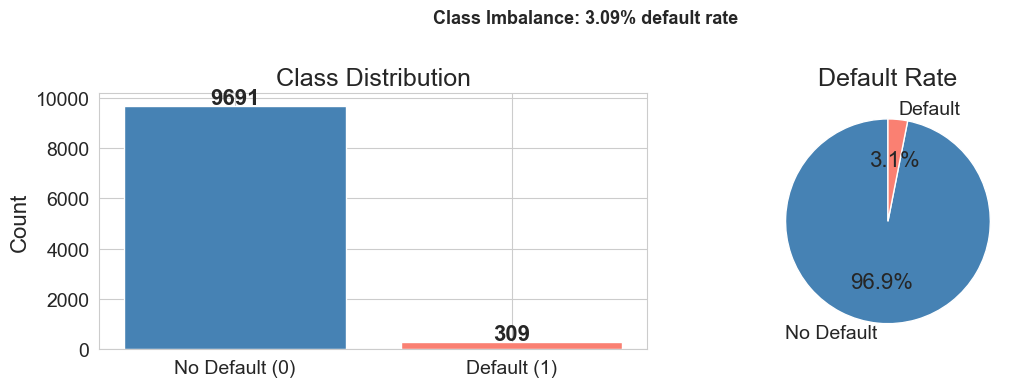

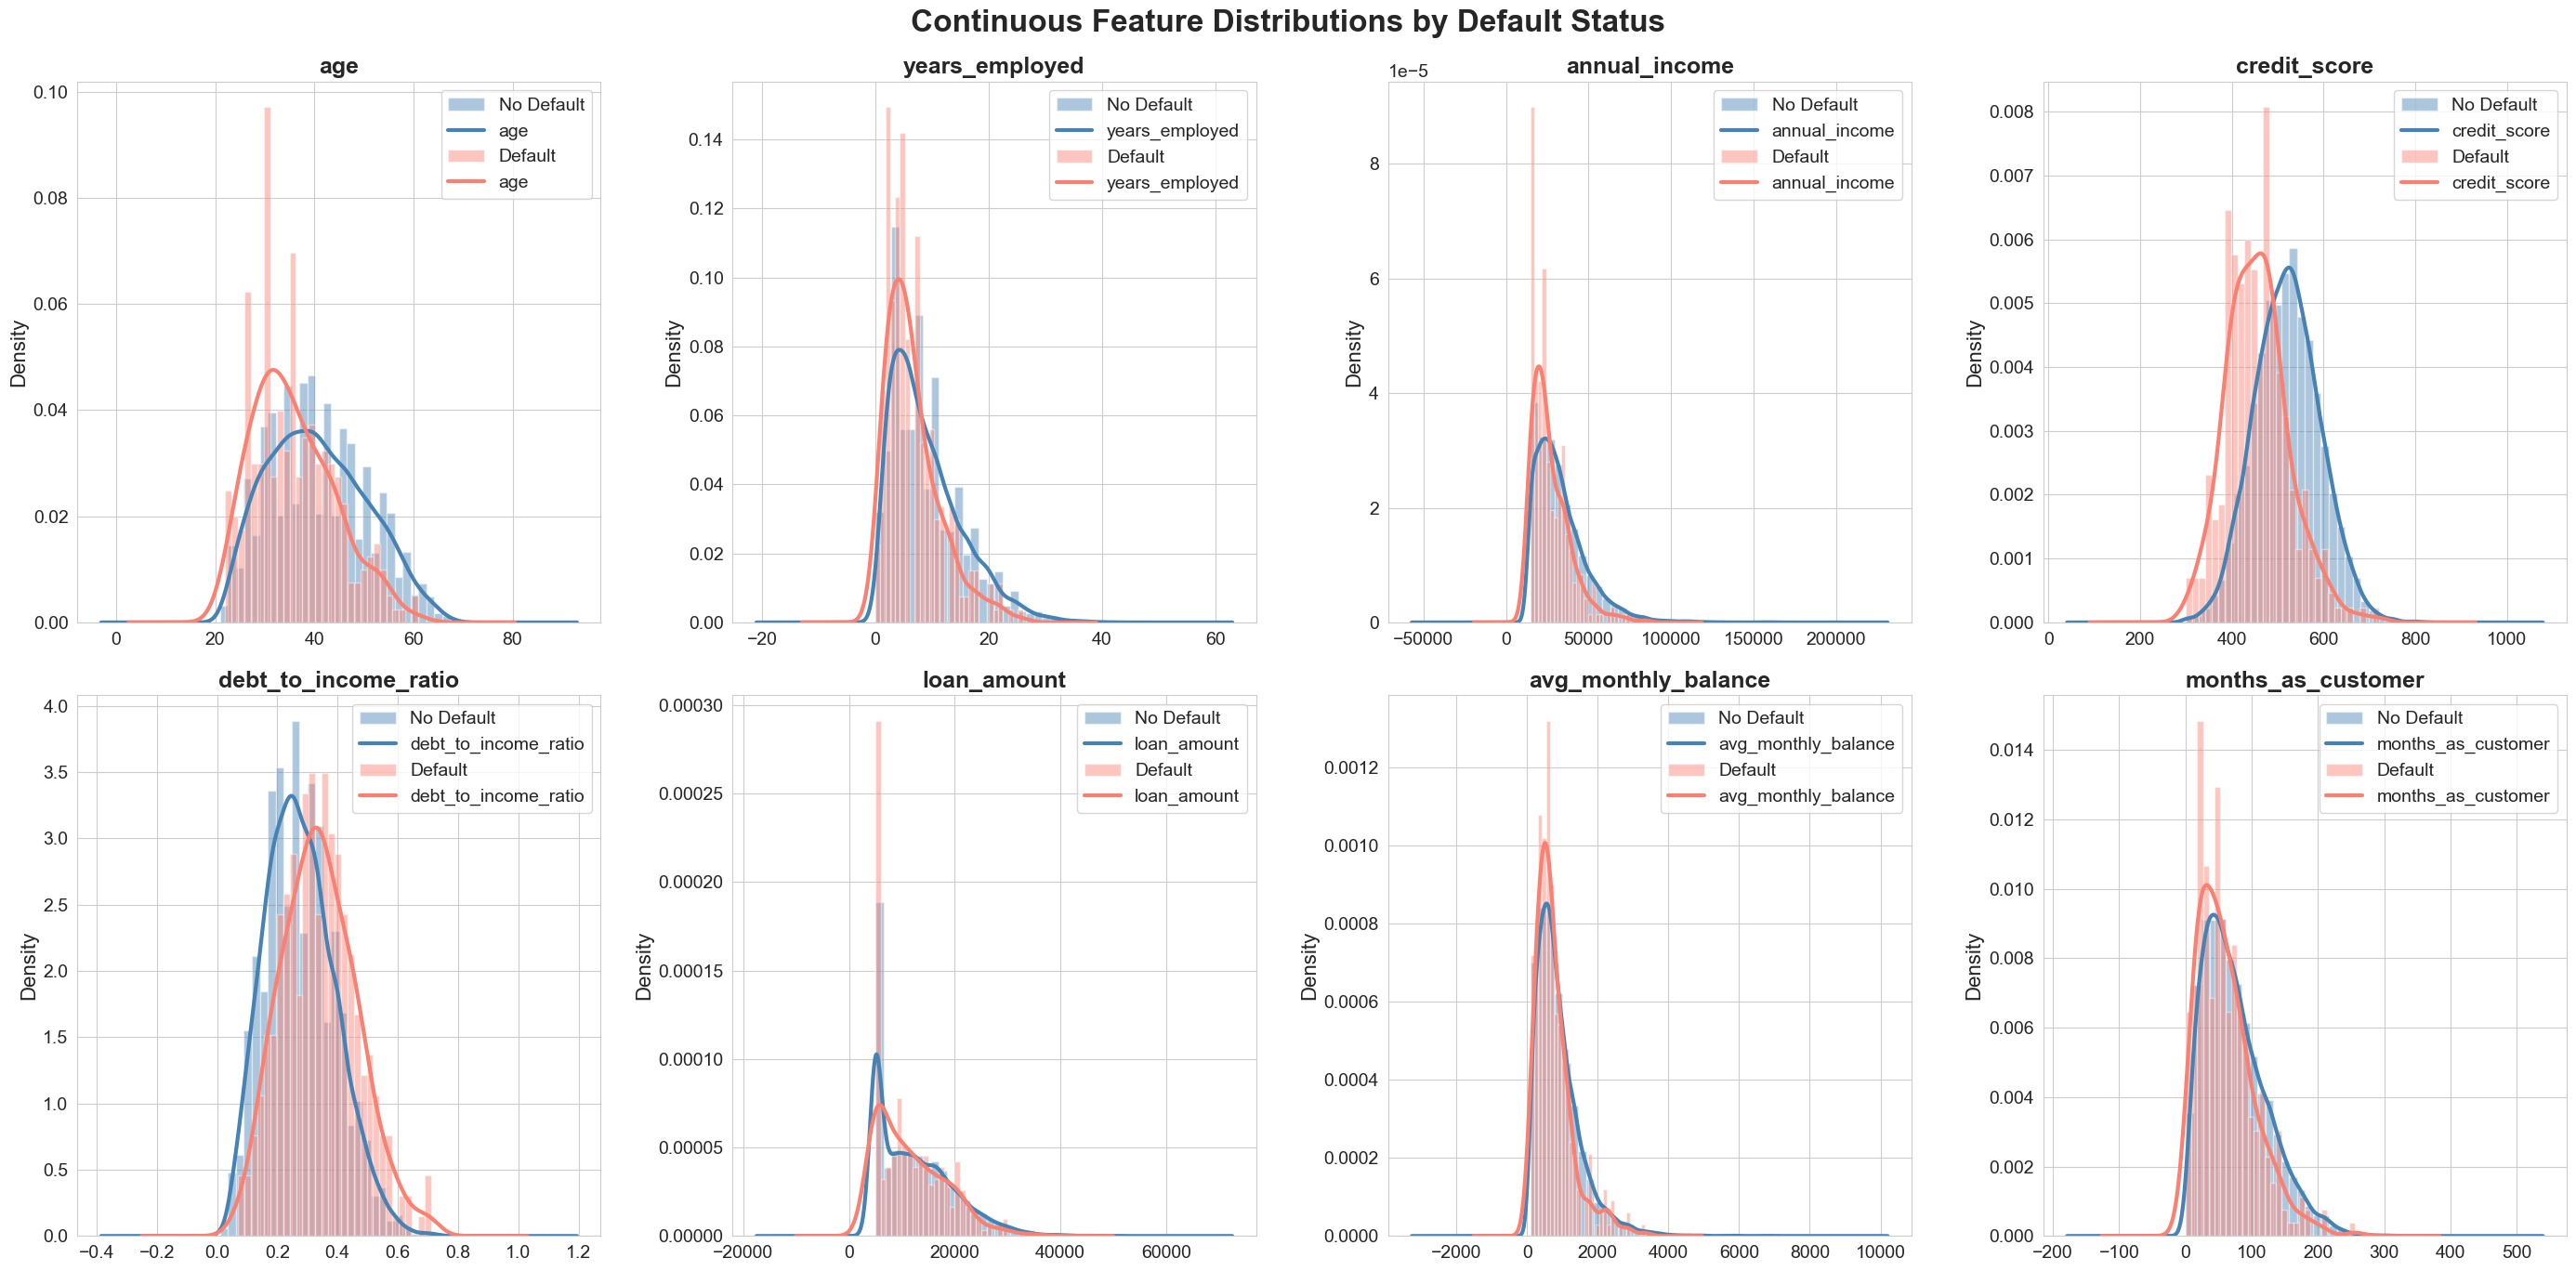

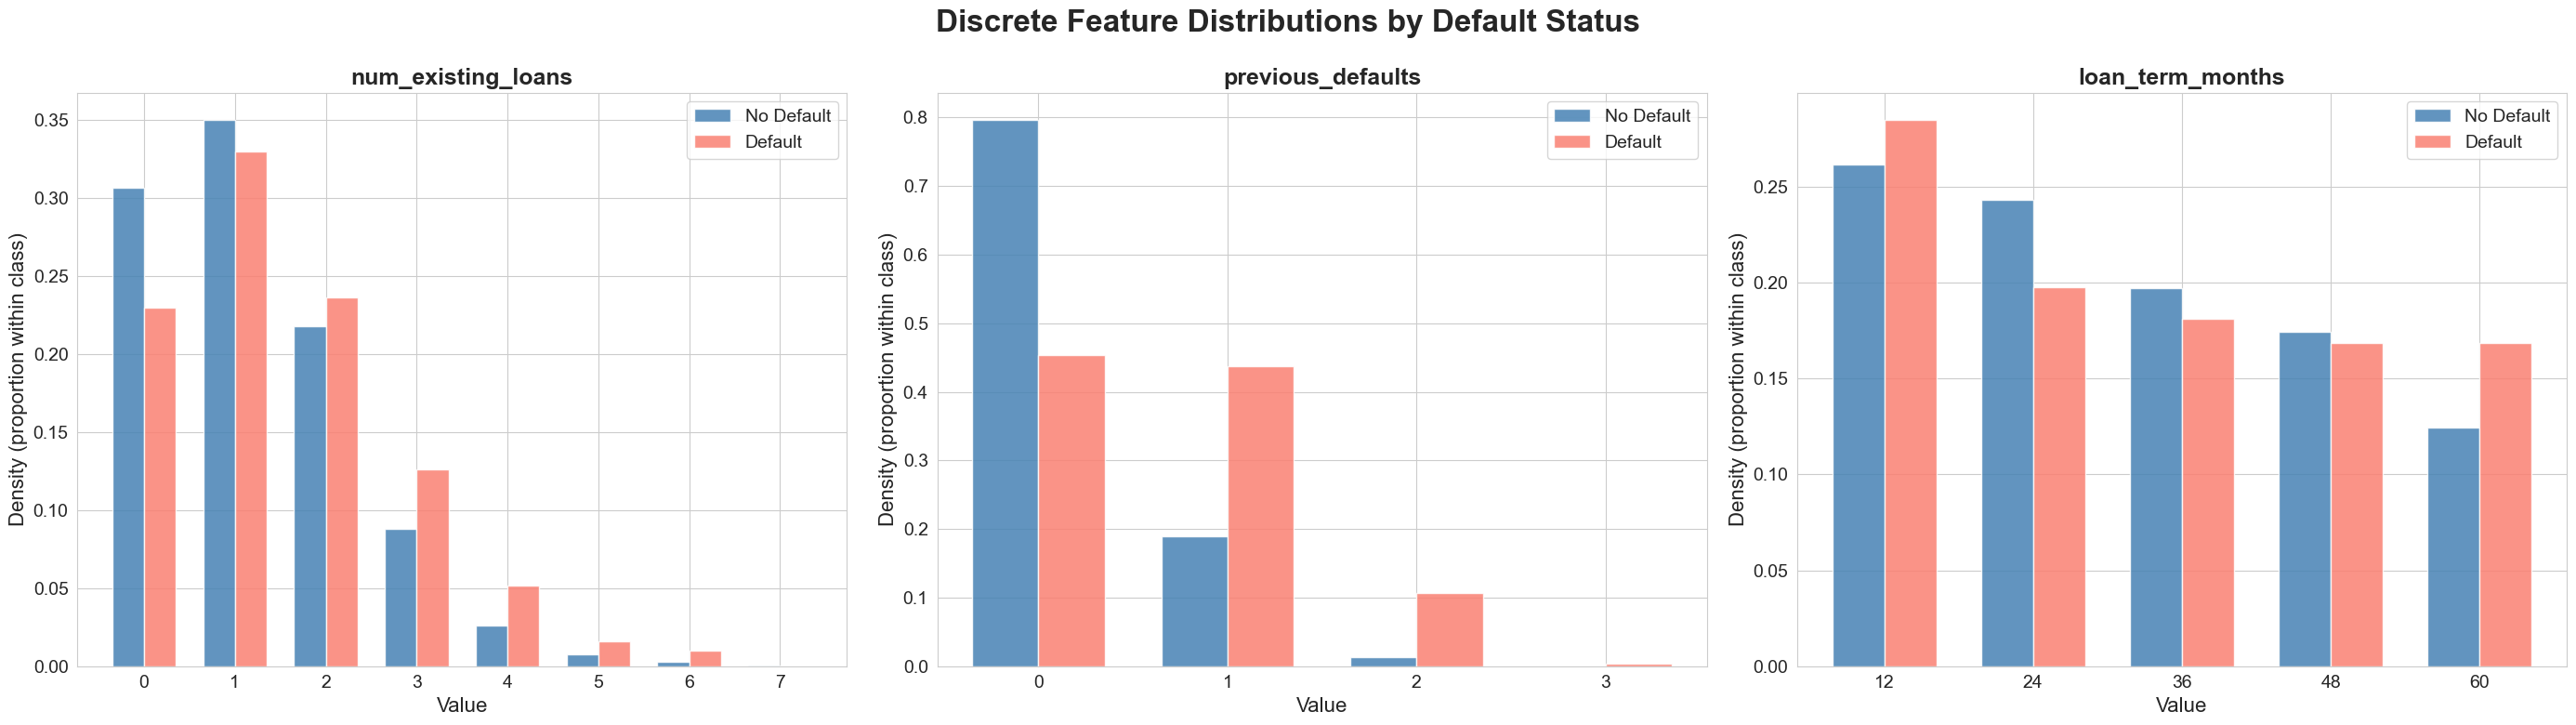

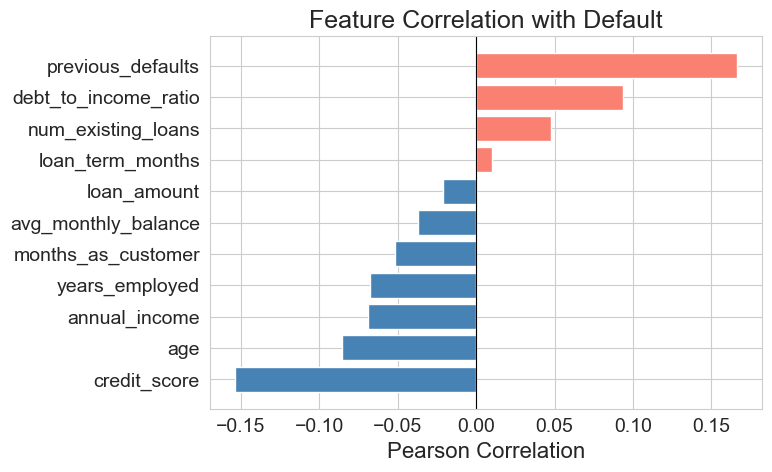

credit_score           -0.153937
age                    -0.085838
annual_income          -0.068974
years_employed         -0.067448
months_as_customer     -0.051975
avg_monthly_balance    -0.037391
loan_amount            -0.021458
loan_term_months        0.010192
num_existing_loans      0.047559
debt_to_income_ratio    0.093407
previous_defaults       0.166314

--- Default Rate by Loan Purpose ---
                    Default Rate  Count
loan_purpose                           
debt_consolidation        0.0420   2046
business                  0.0378   1456
personal                  0.0308   3082
education                 0.0278    971
home_improvement          0.0188   2445


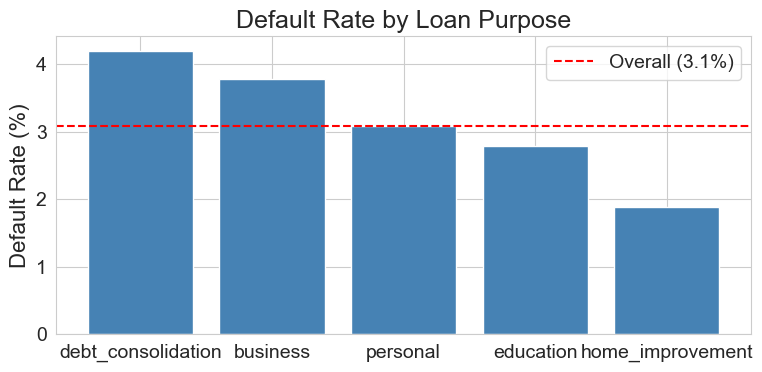

In [25]:
# --- Class distribution ---
import os; os.makedirs('plots', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['default'].value_counts()
axes[0].bar(['No Default (0)', 'Default (1)'], counts.values, color=['steelblue', 'salmon'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['No Default', 'Default'], autopct='%1.1f%%',
            colors=['steelblue', 'salmon'], startangle=90)
axes[1].set_title('Default Rate')
plt.suptitle(f'Class Imbalance: {df["default"].mean():.2%} default rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

# --- Split features into continuous and discrete ---
continuous_features = ['age', 'years_employed', 'annual_income', 'credit_score',
                       'debt_to_income_ratio', 'loan_amount', 'avg_monthly_balance', 'months_as_customer']

discrete_features = ['num_existing_loans', 'previous_defaults', 'loan_term_months']
# ---- Global font scaling ----
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

# --- Figure 2: Continuous feature distributions with KDE ---
n_cols = 4
n_rows = -(-len(continuous_features) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(28, n_rows * 7))
axes = axes.flatten()

for i, feat in enumerate(continuous_features):
    ax = axes[i]

    for val, label, color in [(0, 'No Default', 'steelblue'), (1, 'Default', 'salmon')]:
        subset = df[df['default'] == val][feat]

        ax.hist(subset, bins=30, alpha=0.45,
                label=label, color=color, density=True)

        subset.plot.kde(ax=ax, color=color, lw=3)

    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("Density")
    ax.legend()

for j in range(len(continuous_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Continuous Feature Distributions by Default Status",
    fontsize=24,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("plots/feature_distributions_continuous.png",
            dpi=160, bbox_inches='tight')
plt.show()


# --- Figure 3: Discrete feature distributions ---
n0 = (df['default'] == 0).sum()
n1 = (df['default'] == 1).sum()

fig, axes = plt.subplots(1, len(discrete_features), figsize=(28, 8))

for i, feat in enumerate(discrete_features):

    ax = axes[i]

    sorted_vals = sorted(df[feat].unique())
    x = np.arange(len(sorted_vals))
    width = 0.35

    density_0 = [
        df[(df['default'] == 0) & (df[feat] == v)].shape[0] / n0
        for v in sorted_vals
    ]

    density_1 = [
        df[(df['default'] == 1) & (df[feat] == v)].shape[0] / n1
        for v in sorted_vals
    ]

    ax.bar(x - width/2, density_0, width,
           label='No Default', color='steelblue', alpha=0.85)

    ax.bar(x + width/2, density_1, width,
           label='Default', color='salmon', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(sorted_vals)

    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel("Value")
    ax.set_ylabel("Density (proportion within class)")
    ax.legend()

plt.suptitle(
    "Discrete Feature Distributions by Default Status",
    fontsize=24,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("plots/feature_distributions_discrete.png",
            dpi=160, bbox_inches='tight')
plt.show()
# --- Correlation with default ---
numeric_features = continuous_features + discrete_features
corr = df[numeric_features + ['default']].corr()['default'].drop('default').sort_values()
plt.figure(figsize=(8, 5))
colors_corr = ['salmon' if v > 0 else 'steelblue' for v in corr.values]
plt.barh(corr.index, corr.values, color=colors_corr)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Default')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.savefig('plots/correlation.png', dpi=120, bbox_inches='tight')
plt.show()
print(corr.to_string())

# --- Default rate by loan_purpose ---
purpose_default = df.groupby('loan_purpose')['default'].agg(['mean', 'count']).sort_values('mean', ascending=False)
purpose_default.columns = ['Default Rate', 'Count']
print("\n--- Default Rate by Loan Purpose ---")
print(purpose_default.round(4))
plt.figure(figsize=(8, 4))
plt.bar(purpose_default.index, purpose_default['Default Rate'] * 100, color='steelblue')
plt.axhline(df['default'].mean() * 100, color='red', linestyle='--', label=f'Overall ({df["default"].mean():.1%})')
plt.title('Default Rate by Loan Purpose')
plt.ylabel('Default Rate (%)')
plt.legend()
plt.tight_layout()
plt.savefig('plots/default_by_purpose.png', dpi=120, bbox_inches='tight')
plt.show()


Text(0.5, 1.0, 'Correlation Matrix of Numeric Features and Default')

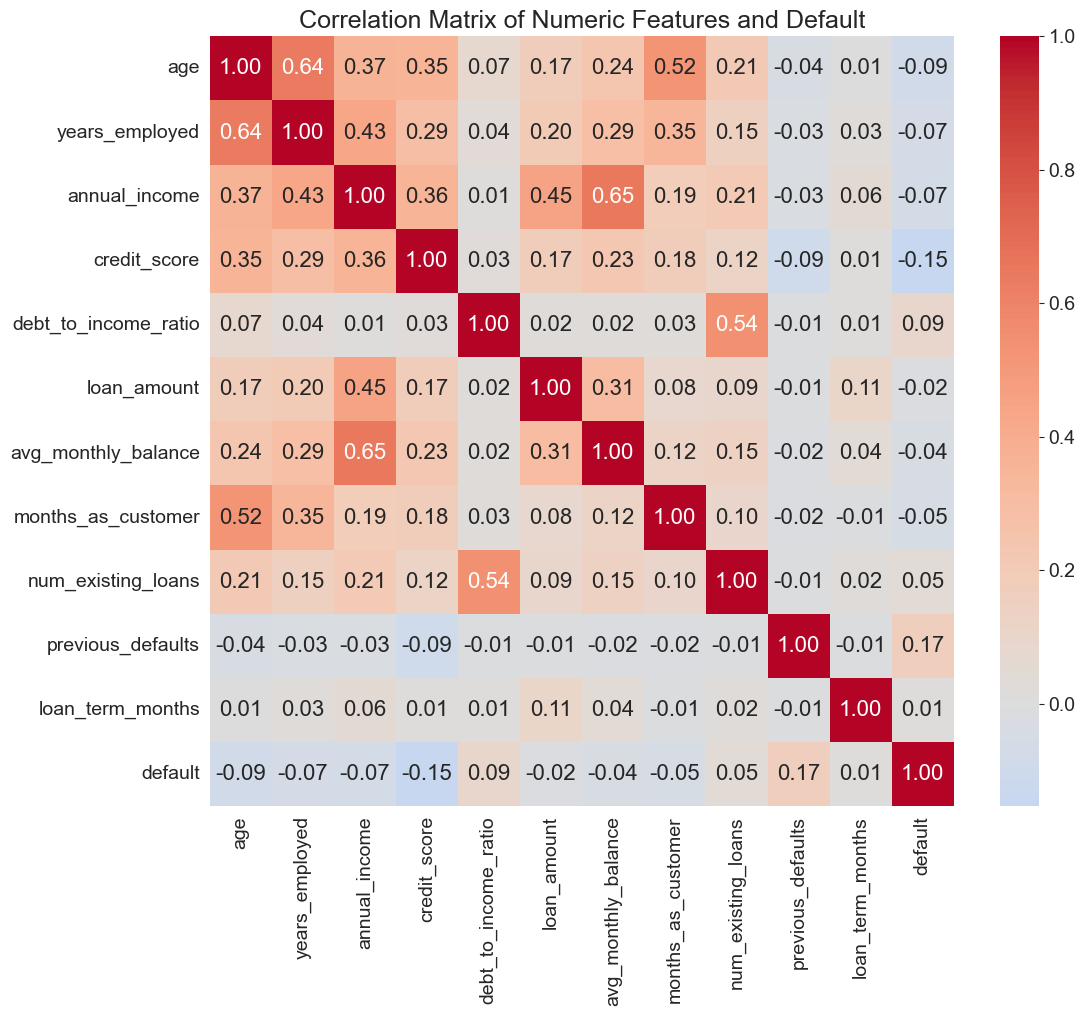

In [5]:
# correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(df[numeric_features + ['default']].corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numeric Features and Default')

### EDA Observations

*Summarize your key findings here:*

1. The dataset exhibits severe imbalance with 'defaults' being the minority, so a naive baseline that always predicts 'no default' ,would achieve an extremely high accuracy(96.9%) - accuracy is a misleading metric here

2. Continuous Feature Distributions:  
Defaulters tend to have lower age, slightly lower years_employed, slightly lower annual_income, and lower credit_score compared to non-defaults - suggesting that not financially stable profiles are more likely to default.

3. Discrete Features:  
Previous_defaults: customers with 1+ previous defaults are dramatically more likely to default again (~45% of defaults have previous_defaults ≥ 1 vs ~20% of non-defaults)  
Loan_term_months: longer term loans (60 months) appear slightly more associated with defaults  
Num_existing_loans: Non-defaulters are concentrated at 1 existing loan (~35%), while defaulters are more spread out (higher proportions at 2, 3, 4+ loans).Having more existing loans is associated with higher default risk

4. Strongest Predictors:  
previous_defaults → strongest positive predictor of default by far  
debt_to_income_ratio → second strongest positive predictor  
num_existing_loans → moderate positive correlation  
credit_score, age, annual_income → negative correlation (higher values = less likely to default)

5. Default Rate by Loan Purpose:  
Highest risk: debt_consolidation (4.2%) and business (3.8%)  
Lowest risk: home_improvement (1.9%)

## 2. Data Preprocessing

- Encode categorical features
- Train/test split (use stratification to maintain class proportions)
- Scale features

In [6]:
# One-hot encode loan_purpose (drop_first=True, Keeping all 5 creates multicollinearity, which can hurt models like Logistic Regression )
df_model = pd.get_dummies(df, columns=["loan_purpose"], drop_first=True)

# Features and target
feature_cols = [c for c in df_model.columns if c != "default"]
X = df_model[feature_cols]
y = df_model["default"]

print(f"Features ({len(feature_cols)}): {list(feature_cols)}")
print(f"Class distribution - 0: {(y==0).sum()}, 1: {(y==1).sum()}, rate: {y.mean():.2%}")

# Stratified train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Train default rate: {y_train.mean():.2%}, Test default rate: {y_test.mean():.2%}")

# --- Selective Scaling ---
# StandardScaler for continuous features (unbounded, roughly normal)
continuous_features = ["age", "years_employed", "annual_income", "credit_score",
                       "debt_to_income_ratio", "loan_amount", "avg_monthly_balance",
                       "months_as_customer"]

# MinMaxScaler for discrete count features (bounded integers)
discrete_features = ["num_existing_loans", "previous_defaults", "loan_term_months"]

# Binary dummy variables: no scaling needed (already 0/1)
binary_features = [c for c in feature_cols if c.startswith("loan_purpose_")]

preprocessor = ColumnTransformer(transformers=[
    ("std",  StandardScaler(), continuous_features),
    ("minmax", MinMaxScaler(), discrete_features),
    ("pass", "passthrough", binary_features)
])

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled  = preprocessor.transform(X_test)
print("\nScaling complete.")
print(f"  Continuous ({len(continuous_features)}): StandardScaler")
print(f"  Discrete   ({len(discrete_features)}): MinMaxScaler")
print(f"  Binary     ({len(binary_features)}): no scaling (passthrough)")


Features (15): ['age', 'years_employed', 'annual_income', 'credit_score', 'debt_to_income_ratio', 'num_existing_loans', 'previous_defaults', 'loan_amount', 'loan_term_months', 'avg_monthly_balance', 'months_as_customer', 'loan_purpose_debt_consolidation', 'loan_purpose_education', 'loan_purpose_home_improvement', 'loan_purpose_personal']
Class distribution - 0: 9691, 1: 309, rate: 3.09%
Train size: 8000, Test size: 2000
Train default rate: 3.09%, Test default rate: 3.10%

Scaling complete.
  Continuous (8): StandardScaler
  Discrete   (3): MinMaxScaler
  Binary     (4): no scaling (passthrough)


## 3. Stakeholder Cost Structures

Before building any models, define the cost structure for each stakeholder and calculate their break-even thresholds.

**Reminder:** The break-even formula is $P^* = \frac{C_{FP}}{C_{FP} + C_{FN}}$ where $C_{FP}$ is the **incremental** cost of rejecting a good loan ($\text{TN} - \text{FP}$) and $C_{FN}$ is the **incremental** cost of approving a default ($\text{TP} - \text{FN}$). These are the differences between the correct and incorrect decision for each type of applicant.

In [7]:
# Cost structures from the project brief
# TN = approve good loan (no default), FN = approve default, FP = reject good loan, TP = reject default
stakeholders = {
    'CFO': {'TN': 2400,   'FN': -15000, 'FP': 0,      'TP': 0,
            'name': 'Maria Georgiou (CFO)', 'goal': 'Maximize Profit'},
    'CRO': {'TN': 0,      'FN': -45000, 'FP': -500,   'TP': 0,
            'name': 'Andreas Konstantinou (CRO)', 'goal': 'Minimize Risk'},
    'CGO': {'TN': 8000,   'FN': -12000, 'FP': -10000, 'TP': 0,
            'name': 'Elena Papadopoulou (CGO)', 'goal': 'Maximize Growth'},
}

print("=" * 65)
print(f"{'Stakeholder':<8} {'C_FP (incr.)':<16} {'C_FN (incr.)':<16} {'P* (break-even)'}")
print("=" * 65)
for key, s in stakeholders.items():
    # Incremental cost of FP = TN - FP (swing between correct & wrong for good loan)
    c_fp = s['TN'] - s['FP']
    # Incremental cost of FN = TP - FN (swing between correct & wrong for default)
    c_fn = s['TP'] - s['FN']
    p_star = c_fp / (c_fp + c_fn)
    s['C_FP'] = c_fp
    s['C_FN'] = c_fn
    s['p_star'] = p_star
    print(f"{key:<8} €{c_fp:>12,.0f}   €{c_fn:>12,.0f}   {p_star:.4f}  ({p_star:.1%})")

print("=" * 65)
print("\nInterpretation:")
print(f"  CFO p*={stakeholders['CFO']['p_star']:.1%}: Reject only if >13.8% chance of default / profit-maximizing, fairly permissive")
print(f"  CRO p*={stakeholders['CRO']['p_star']:.1%}: Reject if >1.1% chance of default / very conservative, risk-averse")
print(f"  CGO p*={stakeholders['CGO']['p_star']:.1%}: Reject only if >60% chance of default / very permissive, growth-oriented")


Stakeholder C_FP (incr.)     C_FN (incr.)     P* (break-even)
CFO      €       2,400   €      15,000   0.1379  (13.8%)
CRO      €         500   €      45,000   0.0110  (1.1%)
CGO      €      18,000   €      12,000   0.6000  (60.0%)

Interpretation:
  CFO p*=13.8%: Reject only if >13.8% chance of default / profit-maximizing, fairly permissive
  CRO p*=1.1%: Reject if >1.1% chance of default / very conservative, risk-averse
  CGO p*=60.0%: Reject only if >60% chance of default / very permissive, growth-oriented


**Do these thresholds make intuitive sense given each stakeholder's priorities?**

The thresholds align well with each stakeholder's priorities:

**CFO (p\* = 13.8% — Maximize Profit):**
The CFO only rejects a loan if there is greater than a 13.8% chance of default. This is expected since approving a good loan generates €2,400 in profit, so the CFO is willing to take on moderate risk as long as the expected return outweighs the expected loss. This makes sense for a mindset focused on maximizing profit.

**CRO (p\* = 1.1% — Minimize Risk):**
The CRO rejects any loan with greater than a 1.1% chance of default — an extremely conservative threshold. This reflects the fact that a single approved default costs €45,000 in risk exposure, while rejecting a good loan only costs €500. The asymmetry between these two outcomes justifies being this strict when it comes to approving risky loans.

**CGO (p\* = 60.0% — Maximize Growth):**
The CGO only rejects a loan if there is greater than a 60% chance of default — the most permissive threshold of all three. This reflects the growth officer's priority of maximizing loan approvals to drive business expansion. With an €8,000 reward for approving good loans and a €10,000 penalty for rejecting them, the CGO needs to be very confident someone will default before turning them away.

Overall, the ordering **CRO < CFO < CGO** makes perfect intuitive sense — from most risk-averse to most growth-oriented.

## 4. Helper Functions

These utility functions will be used throughout the analysis.

In [8]:
def predict_with_threshold(probabilities, threshold=0.5):
    """Convert predicted probabilities to binary predictions using a custom threshold."""
    return (probabilities >= threshold).astype(int)


def calculate_profit_per_1000(y_true, y_pred, cost_structure):
    """Calculate expected profit per 1,000 applications for a given cost structure.
    
    Parameters
    ----------
    y_true : array-like, true labels (1=default, 0=no default)
    y_pred : array-like, predicted labels (1=reject, 0=approve)
    cost_structure : dict with keys 'TN', 'FP', 'FN', 'TP'
    
    Returns
    -------
    float : expected profit scaled to 1,000 applications
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total = tn + fp + fn + tp
    
    profit = (tn * cost_structure['TN'] + 
              fp * cost_structure['FP'] + 
              fn * cost_structure['FN'] + 
              tp * cost_structure['TP'])
    
    return profit / total * 1000

## 5. Handling Imbalanced Data

The dataset has ~3% defaults, a 31:1 class imbalance. You must address this.

Train models using **two approaches** and compare them:
1. **With balancing:** `class_weight='balanced'` or SMOTE (pick one or try both)
2. **Without balancing:** train on the original imbalanced data

> **Why compare?**
> Using `class_weight='balanced'` or SMOTE improves recall at the default 0.5 threshold, but it **inflates the predicted probabilities**. This means the break-even thresholds from Section 3 won't directly match the empirically optimal thresholds you find by sweeping. Recall from the bank_credit example in class: even there the theoretical optimum (0.25) differed slightly from the empirical one (0.21). With heavy imbalance and balancing, the gap can be much larger.
>
> Training **without** balancing keeps the predicted probabilities calibrated, so the break-even formula works more directly. You then find the right cutoff by sweeping. Compare the two approaches: how do the optimal thresholds differ? How does calibration differ?

In [9]:
# Apply SMOTE to training data
if SMOTE_AVAILABLE:
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
    print(f"Before SMOTE: {pd.Series(y_train).value_counts().to_dict()}")
    print(f"After  SMOTE: {pd.Series(y_train_smote).value_counts().to_dict()}")
    print(f"SMOTE expanded training set from {len(y_train):,} to {len(y_train_smote):,} samples")
else:
    # Fall back: use class_weight='balanced' in models
    X_train_smote, y_train_smote = X_train_scaled, y_train
    print("SMOTE not available; will use class_weight='balanced' in applicable models.")


Before SMOTE: {0: 7753, 1: 247}
After  SMOTE: {0: 7753, 1: 7753}
SMOTE expanded training set from 8,000 to 15,506 samples


## 6. Train and Compare Models

Train at least 5 classifiers. For each, compute: Accuracy, Precision, Recall, F1, AUC.

**Question to answer:** What accuracy does a "predict all no-default" baseline achieve? Why is accuracy misleading here?

In [10]:
# Define models (trained on SMOTE-balanced data)
models_balanced = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'LDA':                 LinearDiscriminantAnalysis(),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Naive Bayes':         GaussianNB(),
}

results = []
trained_models = {}

for name, model in models_balanced.items():
    model.fit(X_train_smote, y_train_smote)  # Train on SMOTE-balanced data
    trained_models[name] = model
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    results.append({
        'Model': name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'F1':        f1_score(y_test, y_pred, zero_division=0),
        'AUC':       roc_auc_score(y_test, y_prob),
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
print("=== Model Comparison (trained on SMOTE-balanced data) ===")
print(results_df.sort_values('AUC', ascending=False).to_string())


=== Model Comparison (trained on SMOTE-balanced data) ===
                     Accuracy  Precision  Recall      F1     AUC
Model                                                           
Logistic Regression    0.7880     0.0923  0.6613  0.1621  0.8161
LDA                    0.7800     0.0891  0.6613  0.1571  0.8143
Gradient Boosting      0.9570     0.2273  0.1613  0.1887  0.7610
Random Forest          0.9620     0.2308  0.0968  0.1364  0.7415
Naive Bayes            0.6735     0.0583  0.6290  0.1067  0.7337
KNN                    0.8275     0.0673  0.3548  0.1131  0.6360
Decision Tree          0.9295     0.1376  0.2419  0.1754  0.5967


In [11]:
# Baseline: predict "no default" for everyone
baseline_acc = accuracy_score(y_test, np.zeros(len(y_test)))
baseline_recall = recall_score(y_test, np.zeros(len(y_test)), zero_division=0)
print(f"Naive Baseline (predict all 0): Accuracy = {baseline_acc:.4f}, Recall = {baseline_recall:.4f}")
print(f" A model that always predicts 'no default' achieves {baseline_acc:.1%} accuracy")
print(f"  yet catches ZERO defaults (recall = 0). Accuracy is misleading because")
print(f"  the dataset is heavily imbalanced (~3% defaults). The majority class")
print(f"  dominates the metric. We should instead focus on AUC, Recall, and F1.")


Naive Baseline (predict all 0): Accuracy = 0.9690, Recall = 0.0000
 A model that always predicts 'no default' achieves 96.9% accuracy
  yet catches ZERO defaults (recall = 0). Accuracy is misleading because
  the dataset is heavily imbalanced (~3% defaults). The majority class
  dominates the metric. We should instead focus on AUC, Recall, and F1.


## 7. Balanced vs. Unbalanced Comparison

From Section 6, **Logistic Regression** achieved the highest AUC among all models trained on SMOTE-balanced data, followed by **LDA**. We compare both models trained with and without SMOTE to decide which approach to carry forward.

**Approach:** For each model we compare:
1. **AUC:** Does balancing help or hurt the model's ranking ability?
2. **Probability calibration:** How do the predicted probability distributions differ?
3. **Optimal thresholds (F1 illustration):** We sweep thresholds using F1 score purely to **demonstrate** that the optimal cutoff shifts when probabilities are inflated by SMOTE. This is *not* a switch to F1 as our evaluation metric.

Based on these comparisons, we decide which training approach to use going forward.

COMPARISON: Logistic Regression — Balanced vs. Unbalanced
  WITHOUT balancing (original data) → AUC: 0.8227
  WITH SMOTE balancing             → AUC: 0.8161

  Δ AUC = +0.0065


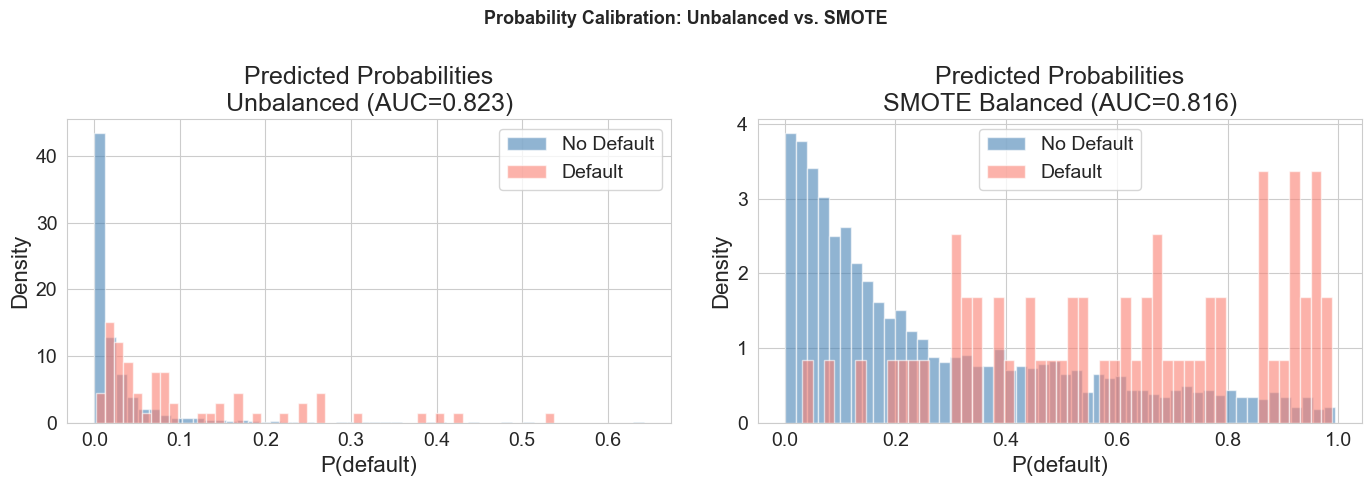

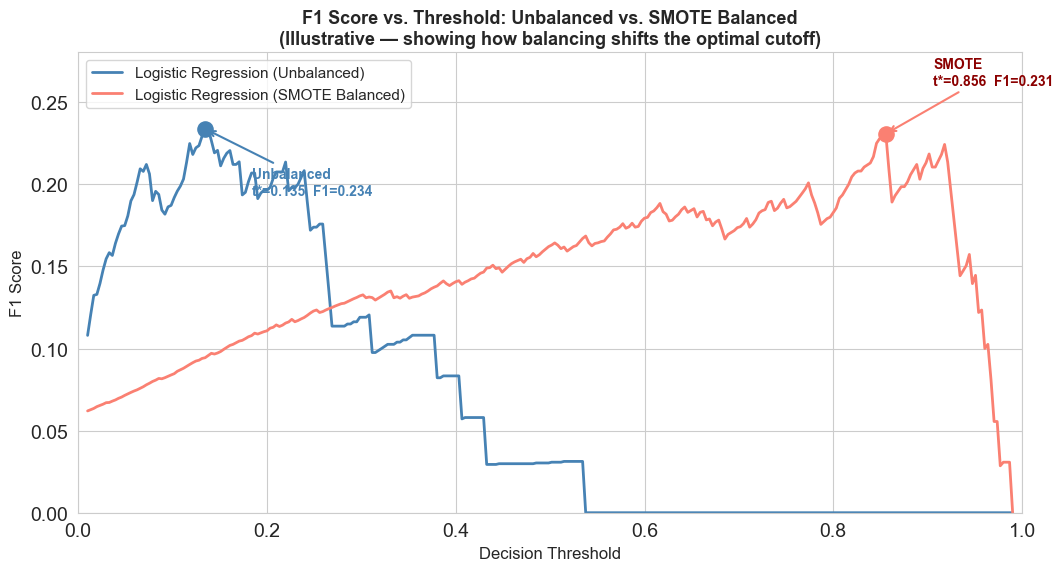

Optimal F1 threshold (Unbalanced): 0.135  →  F1 = 0.234
Optimal F1 threshold (SMOTE):      0.856  →  F1 = 0.231

CONCLUSION

The unbalanced model achieves a slightly higher AUC (0.8227 vs. 0.8161).
More importantly, its predicted probabilities remain calibrated — a prediction
of P(default)=0.10 genuinely reflects ~10% real-world default risk.

The F1 plot above illustrates this clearly: SMOTE inflates the probabilities,
which shifts the optimal threshold (for F1 score) from 0.135 (unbalanced) to
0.856 (balanced). The break-even thresholds from Section 3 (e.g.,
CFO's 13.8%) only make intuitive sense with calibrated probabilities.

Since we will be optimizing thresholds by sweeping (Sections 10–12), we do not
need SMOTE to push recall up at the default 0.5 cutoff. Instead, we want the
predicted probabilities to mean what they say, so that the thresholds we find
correspond to real-world default risk levels.

→ From this point forward, we proceed with the UNBALANCED Logistic Regression.
  

In [12]:
# ---- Balanced vs. Unbalanced: Logistic Regression (best model by AUC from Section 6) ----

# --- Without balancing (original imbalanced data → calibrated probabilities) ---
lr_unbal = LogisticRegression(max_iter=1000, random_state=42)
lr_unbal.fit(X_train_scaled, y_train)
prob_unbal = lr_unbal.predict_proba(X_test_scaled)[:, 1]
auc_unbal = roc_auc_score(y_test, prob_unbal)

# --- With SMOTE balancing (already trained in Section 6) ---
lr_bal = trained_models['Logistic Regression']
prob_bal = lr_bal.predict_proba(X_test_scaled)[:, 1]
auc_bal = roc_auc_score(y_test, prob_bal)

print("=" * 60)
print("COMPARISON: Logistic Regression — Balanced vs. Unbalanced")
print("=" * 60)
print(f"  WITHOUT balancing (original data) → AUC: {auc_unbal:.4f}")
print(f"  WITH SMOTE balancing             → AUC: {auc_bal:.4f}")
print(f"\n  Δ AUC = {auc_unbal - auc_bal:+.4f}")
print("=" * 60)

# ---- 1. Probability calibration comparison ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, probs, title in [
    (axes[0], prob_unbal, f'Unbalanced (AUC={auc_unbal:.3f})'),
    (axes[1], prob_bal,   f'SMOTE Balanced (AUC={auc_bal:.3f})')
]:
    ax.hist(probs[y_test == 0], bins=50, alpha=0.6, label='No Default', color='steelblue', density=True)
    ax.hist(probs[y_test == 1], bins=50, alpha=0.6, label='Default',    color='salmon', density=True)
    ax.set_title(f'Predicted Probabilities\n{title}')
    ax.set_xlabel('P(default)')
    ax.set_ylabel('Density')
    ax.legend()
plt.suptitle('Probability Calibration: Unbalanced vs. SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/calibration_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

# ---- 2. F1 vs. Threshold — illustrative only ----
# Purpose: show that balancing SHIFTS the optimal threshold, not to adopt F1 as our metric.
thresholds_f1 = np.linspace(0.01, 0.99, 300)

f1_unbal = []
f1_bal   = []

for t in thresholds_f1:
    f1_unbal.append(f1_score(y_test, (prob_unbal >= t).astype(int), zero_division=0))
    f1_bal.append(  f1_score(y_test, (prob_bal   >= t).astype(int), zero_division=0))

best_idx_unbal = int(np.argmax(f1_unbal))
best_idx_bal   = int(np.argmax(f1_bal))
best_t_unbal   = thresholds_f1[best_idx_unbal]
best_t_bal     = thresholds_f1[best_idx_bal]
best_f1_unbal  = f1_unbal[best_idx_unbal]
best_f1_bal    = f1_bal[best_idx_bal]

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(thresholds_f1, f1_unbal, color='steelblue', lw=2, label='Logistic Regression (Unbalanced)')
ax.plot(thresholds_f1, f1_bal,   color='salmon',    lw=2, label='Logistic Regression (SMOTE Balanced)')

ax.scatter([best_t_unbal], [best_f1_unbal], color='steelblue', s=120, zorder=5)
ax.scatter([best_t_bal],   [best_f1_bal],   color='salmon',    s=120, zorder=5)

ax.annotate(
    f'Unbalanced\nt*={best_t_unbal:.3f}  F1={best_f1_unbal:.3f}',
    xy=(best_t_unbal, best_f1_unbal),
    xytext=(best_t_unbal + 0.05, best_f1_unbal - 0.04),
    fontsize=10, color='steelblue', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.5)
)
ax.annotate(
    f'SMOTE\nt*={best_t_bal:.3f}  F1={best_f1_bal:.3f}',
    xy=(best_t_bal, best_f1_bal),
    xytext=(best_t_bal + 0.05, best_f1_bal + 0.03),
    fontsize=10, color='darkred', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='salmon', lw=1.5)
)

ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('F1 Score vs. Threshold: Unbalanced vs. SMOTE Balanced\n'
             '(Illustrative — showing how balancing shifts the optimal cutoff)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, max(max(f1_unbal), max(f1_bal)) * 1.2)
plt.tight_layout()
plt.savefig('plots/f1_vs_threshold_balanced_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Optimal F1 threshold (Unbalanced): {best_t_unbal:.3f}  →  F1 = {best_f1_unbal:.3f}")
print(f"Optimal F1 threshold (SMOTE):      {best_t_bal:.3f}  →  F1 = {best_f1_bal:.3f}")

# ---- 3. Conclusion ----
print("\n" + "=" * 60)
print("CONCLUSION")
print("=" * 60)
print(f"""
The unbalanced model achieves a slightly higher AUC ({auc_unbal:.4f} vs. {auc_bal:.4f}).
More importantly, its predicted probabilities remain calibrated — a prediction
of P(default)=0.10 genuinely reflects ~10% real-world default risk.

The F1 plot above illustrates this clearly: SMOTE inflates the probabilities,
which shifts the optimal threshold (for F1 score) from {best_t_unbal:.3f} (unbalanced) to
{best_t_bal:.3f} (balanced). The break-even thresholds from Section 3 (e.g.,
CFO's 13.8%) only make intuitive sense with calibrated probabilities.

Since we will be optimizing thresholds by sweeping (Sections 10–12), we do not
need SMOTE to push recall up at the default 0.5 cutoff. Instead, we want the
predicted probabilities to mean what they say, so that the thresholds we find
correspond to real-world default risk levels.

→ From this point forward, we proceed with the UNBALANCED Logistic Regression.
  All hyperparameter tuning and threshold optimization will use the original
  imbalanced training data. The thresholds we discover will be the actual,
  interpretable probability cutoffs.
""")


COMPARISON: LDA — Balanced vs. Unbalanced
  WITHOUT balancing (original data) → AUC: 0.8103
  WITH SMOTE balancing             → AUC: 0.8143

  Δ AUC = -0.0040


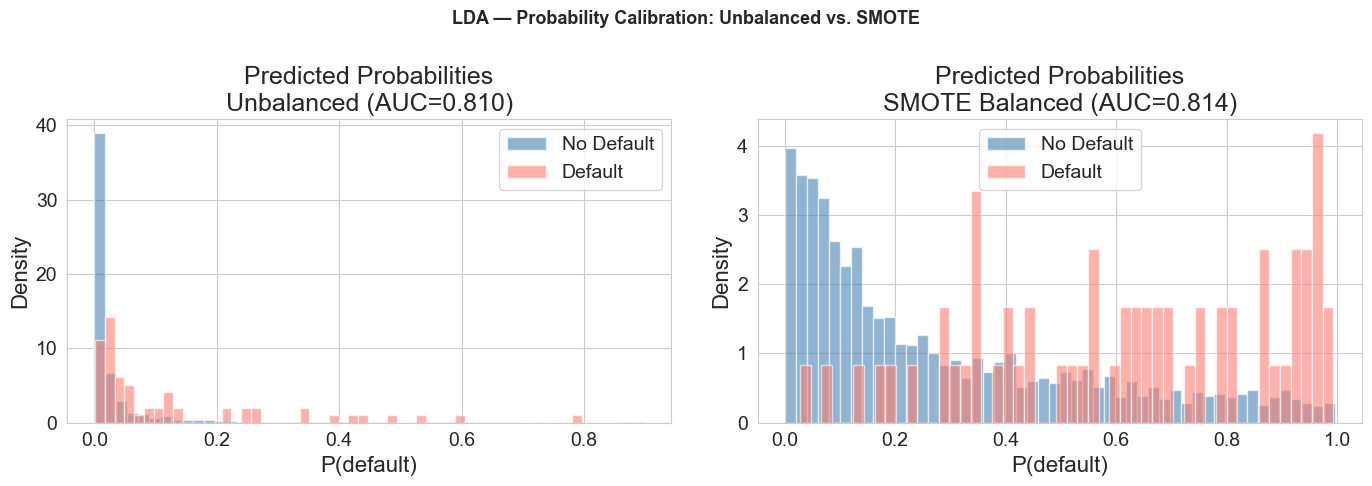


SUMMARY — Both Models: Balanced vs. Unbalanced
Model                      Unbalanced AUC    SMOTE AUC      Δ AUC
------------------------------------------------------------
Logistic Regression                0.8227       0.8161    +0.0065
LDA                                0.8103       0.8143    -0.0040

Both models show comparable or slightly better AUC when trained on the original
imbalanced data. Combined with the calibration advantage discussed above, this
confirms our decision: we proceed with unbalanced training for both models
in the hyperparameter tuning step.



In [13]:
# ---- Balanced vs. Unbalanced: LDA (second-best model by AUC) ----

# --- Without balancing ---
lda_unbal = LinearDiscriminantAnalysis()
lda_unbal.fit(X_train_scaled, y_train)
prob_lda_unbal = lda_unbal.predict_proba(X_test_scaled)[:, 1]
auc_lda_unbal = roc_auc_score(y_test, prob_lda_unbal)

# --- With SMOTE balancing (already trained in Section 6) ---
lda_bal = trained_models['LDA']
prob_lda_bal = lda_bal.predict_proba(X_test_scaled)[:, 1]
auc_lda_bal = roc_auc_score(y_test, prob_lda_bal)

print("=" * 60)
print("COMPARISON: LDA — Balanced vs. Unbalanced")
print("=" * 60)
print(f"  WITHOUT balancing (original data) → AUC: {auc_lda_unbal:.4f}")
print(f"  WITH SMOTE balancing             → AUC: {auc_lda_bal:.4f}")
print(f"\n  Δ AUC = {auc_lda_unbal - auc_lda_bal:+.4f}")
print("=" * 60)

# Probability calibration comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, probs, title in [
    (axes[0], prob_lda_unbal, f'Unbalanced (AUC={auc_lda_unbal:.3f})'),
    (axes[1], prob_lda_bal,   f'SMOTE Balanced (AUC={auc_lda_bal:.3f})')
]:
    ax.hist(probs[y_test == 0], bins=50, alpha=0.6, label='No Default', color='steelblue', density=True)
    ax.hist(probs[y_test == 1], bins=50, alpha=0.6, label='Default',    color='salmon', density=True)
    ax.set_title(f'Predicted Probabilities\n{title}')
    ax.set_xlabel('P(default)')
    ax.set_ylabel('Density')
    ax.legend()
plt.suptitle('LDA — Probability Calibration: Unbalanced vs. SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/lda_calibration_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

# Summary: both models side by side
print("\n" + "=" * 60)
print("SUMMARY — Both Models: Balanced vs. Unbalanced")
print("=" * 60)
print(f"{'Model':<25} {'Unbalanced AUC':>15} {'SMOTE AUC':>12} {'Δ AUC':>10}")
print("-" * 60)
print(f"{'Logistic Regression':<25} {auc_unbal:>15.4f} {auc_bal:>12.4f} {auc_unbal - auc_bal:>+10.4f}")
print(f"{'LDA':<25} {auc_lda_unbal:>15.4f} {auc_lda_bal:>12.4f} {auc_lda_unbal - auc_lda_bal:>+10.4f}")
print("=" * 60)
print("""
Both models show comparable or slightly better AUC when trained on the original
imbalanced data. Combined with the calibration advantage discussed above, this
confirms our decision: we proceed with unbalanced training for both models
in the hyperparameter tuning step.
""")


## 8. Hyperparameter Tuning

Select your top 2 models (by AUC) and tune them with `GridSearchCV`.

- Use `StratifiedKFold` for cross-validation
- Choose an appropriate scoring metric (and justify your choice)
- **Note:** Use `n_jobs=1` to avoid memory issues with parallel processing

In [14]:
# Top 2 models by AUC: Logistic Regression & LDA
# Now tuning on UNBALANCED data (as justified in Section 7)
# Scoring metric: AUC-ROC — we care about ranking/ordering of risk across
# the full range of thresholds, not a single cutoff.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Logistic Regression ---
lr_params = {
    'C':       [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver':  ['lbfgs'],
}
print("Tuning Logistic Regression (on unbalanced data)...")
lr_gs = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    lr_params, scoring='roc_auc', cv=cv, n_jobs=1, verbose=0
)
lr_gs.fit(X_train_scaled, y_train)
print(f"  Best params: {lr_gs.best_params_}")
print(f"  Best mean CV AUC (across 5 folds): {lr_gs.best_score_:.4f}")

# --- LDA ---
lda_params = {
    'shrinkage': [None, 'auto', 0.1, 0.5, 0.9],
    'solver':    ['lsqr'],
}
print("\nTuning LDA (on unbalanced data)...")
lda_gs = GridSearchCV(
    LinearDiscriminantAnalysis(),
    lda_params, scoring='roc_auc', cv=cv, n_jobs=1, verbose=0
)
lda_gs.fit(X_train_scaled, y_train)
print(f"  Best params: {lda_gs.best_params_}")
print(f"  Best mean CV AUC (across 5 folds): {lda_gs.best_score_:.4f}")

# Evaluate tuned models on test set
tuned_models = {'Logistic Regression (Tuned)': lr_gs.best_estimator_,
                'LDA (Tuned)':                 lda_gs.best_estimator_}

for name, model in tuned_models.items():
    prob = model.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, prob)
    print(f"\n{name}: Test AUC = {auc:.4f}")
    trained_models[name] = model

# Use best tuned model for threshold analysis
best_model_name = 'Logistic Regression (Tuned)'
best_model = tuned_models[best_model_name]
best_probs = best_model.predict_proba(X_test_scaled)[:, 1]
print(f"\n→ Best model for threshold optimization: {best_model_name}")
print(f"  Test AUC: {roc_auc_score(y_test, best_probs):.4f}")
print(f"  Trained on: original imbalanced data (calibrated probabilities)")


Tuning Logistic Regression (on unbalanced data)...


  Best params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
  Best mean CV AUC (across 5 folds): 0.8369

Tuning LDA (on unbalanced data)...
  Best params: {'shrinkage': 'auto', 'solver': 'lsqr'}
  Best mean CV AUC (across 5 folds): 0.8303

Logistic Regression (Tuned): Test AUC = 0.8227

LDA (Tuned): Test AUC = 0.8104

→ Best model for threshold optimization: Logistic Regression (Tuned)
  Test AUC: 0.8227
  Trained on: original imbalanced data (calibrated probabilities)


## 9. ROC Curves

Plot all models on a single ROC figure. Which model gives you the most flexibility for threshold optimization?

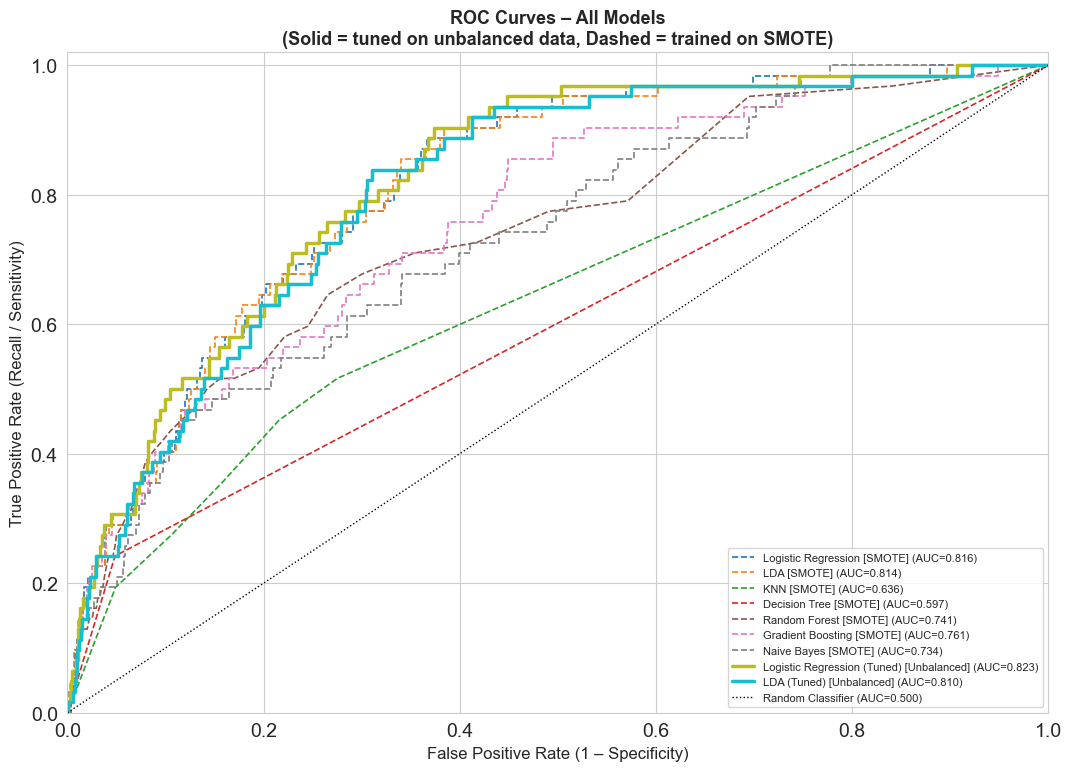


Best model for threshold optimization: Logistic Regression (Tuned) (Unbalanced) (AUC=0.8227)
→ Logistic Regression (Tuned) provides the highest AUC,
  giving the widest range of operating points on the ROC curve.


In [15]:
# Plot ROC curves for all models on a single figure
# Label each model with whether it was trained on SMOTE-balanced or original (unbalanced) data
all_plot_models = {**trained_models}  # includes base (SMOTE) + tuned (unbalanced)

# Models trained on unbalanced data (tuned in Section 8)
unbalanced_models = {'Logistic Regression (Tuned)', 'LDA (Tuned)'}

plt.figure(figsize=(11, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(all_plot_models)))

for (name, model), color in zip(all_plot_models.items(), colors):
    probs = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    lw = 2.5 if 'Tuned' in name else 1.2
    ls = '-' if 'Tuned' in name else '--'
    data_tag = 'Unbalanced' if name in unbalanced_models else 'SMOTE'
    plt.plot(fpr, tpr, color=color, lw=lw, ls=ls,
             label=f'{name} [{data_tag}] (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k:', lw=1, label='Random Classifier (AUC=0.500)')
plt.xlim([0, 1]); plt.ylim([0, 1.02])
plt.xlabel('False Positive Rate (1 – Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=12)
plt.title('ROC Curves – All Models\n(Solid = tuned on unbalanced data, Dashed = trained on SMOTE)',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('plots/roc_all_models.png', dpi=120, bbox_inches='tight')
plt.show()

# Identify best model
aucs = {name: roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])
        for name, model in all_plot_models.items()}
best_name = max(aucs, key=aucs.get)
print(f"\nBest model for threshold optimization: {best_name} (Unbalanced) (AUC={aucs[best_name]:.4f})")
print(f"\u2192 {best_name} provides the highest AUC,")
print("  giving the widest range of operating points on the ROC curve.")


LOGISTIC REGRESSION ODDS RATIOS -- RANKED BY IMPORTANCE
(Features are standardized; odds ratios are per 1 standard deviation increase)

Rank  Feature                          Log-Odds   Odds Ratio                      Interpretation
-----------------------------------------------------------------------------------------------
1     avg_monthly_balance               +3.8740       48.136       48.14x MORE likely to default
2     loan_term_months                  +1.0975        2.997        3.00x MORE likely to default
3     credit_score                      -0.8967        0.408        2.45x LESS likely to default
4     loan_purpose_home_improvement     -0.8484        0.428        2.34x LESS likely to default
5     debt_to_income_ratio              +0.5142        1.672        1.67x MORE likely to default
6     loan_purpose_education            -0.5035        0.604        1.65x LESS likely to default
7     annual_income                     -0.3316        0.718        1.39x LESS likely to 

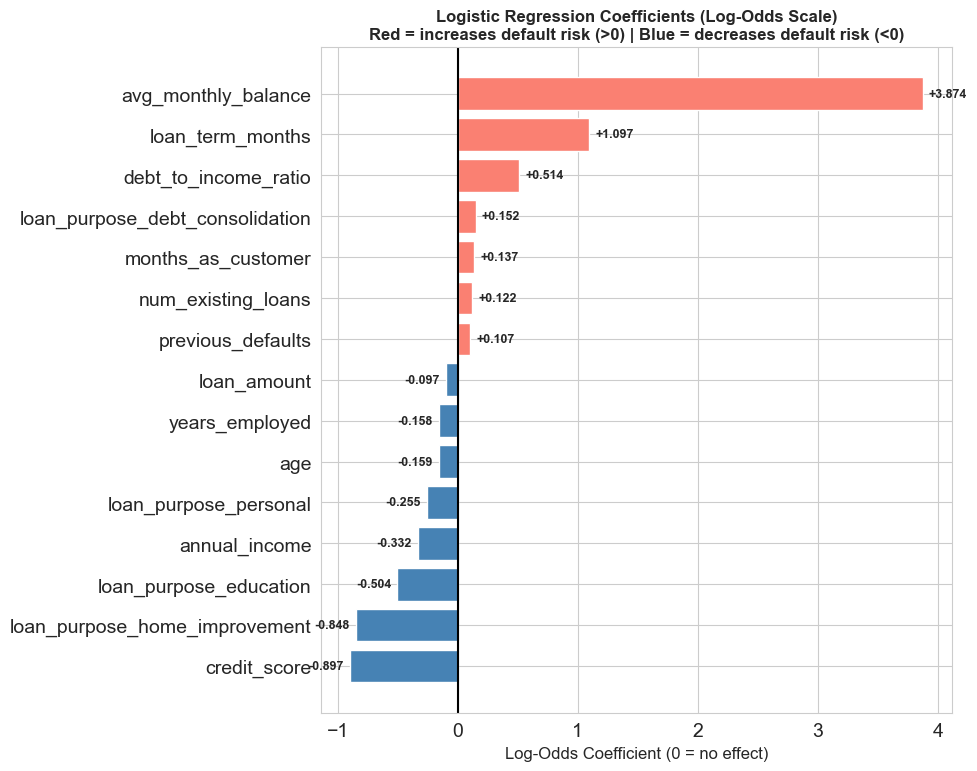


Interpretation of key coefficients:

1. avg_monthly_balance (coef ≈ +3.87):
   avg_monthly_balance has a positive coefficient in this fitted model, meaning that,
   after controlling for the other predictors, higher balances are associated with higher
   default odds. This result should be interpreted cautiously. It does not necessarily mean
   that having more money in the account directly causes default risk to rise. More likely,
   the variable is interacting with other financial characteristics in the dataset, such as
   loan size, debt burden, or customer profile.

2. loan_term_months (coef ≈ +1.10):
   Holding all other variables in the model constant, a one unit increase (in the scaled data)
   in loan_term_months increases the log-odds of default by about 1.10. This makes sense
   because a longer repayment period exposes the borrower to more financial uncertainty
   over time — job loss, income changes, or unexpected expenses become more likely the
   longer the loan runs, in

In [16]:
# ============================================================
# LR Model Coefficients & Odds Ratios — What Drives Default?
# ============================================================
# Since we use Logistic Regression, we can exponentiate the coefficients
# to get ODDS RATIOS: how much the odds of default multiply per one
# standard deviation increase in each feature.
# e.g., OR = 2.5 means "the odds of default are 2.5x higher"

coefs = best_model.coef_[0]
feature_names = feature_cols

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient (log-odds)': coefs,
    'Odds Ratio': np.exp(coefs),
    'Abs Coefficient': np.abs(coefs),
}).sort_values('Abs Coefficient', ascending=False)

# Add interpretation column
def interpret_or(odds_ratio):
    if odds_ratio > 1:
        return f"{odds_ratio:.2f}x MORE likely to default"
    else:
        return f"{1/odds_ratio:.2f}x LESS likely to default"

coef_df['Interpretation (per 1 SD increase)'] = coef_df['Odds Ratio'].apply(interpret_or)

print("=" * 95)
print("LOGISTIC REGRESSION ODDS RATIOS -- RANKED BY IMPORTANCE")
print("(Features are standardized; odds ratios are per 1 standard deviation increase)")
print("=" * 95)
print(f"\n{'Rank':<5} {'Feature':<30} {'Log-Odds':>10} {'Odds Ratio':>12} {'Interpretation':>35}")
print("-" * 95)
for rank, (_, row) in enumerate(coef_df.iterrows(), 1):
    print(f"{rank:<5} {row['Feature']:<30} {row['Coefficient (log-odds)']:>+10.4f} "
          f"{row['Odds Ratio']:>12.3f} {row['Interpretation (per 1 SD increase)']:>35}")
print("=" * 95)

# ---- Log-Odds Coefficient plot (better visualization than odds ratios) ----
fig, ax = plt.subplots(figsize=(10, 8))
sorted_df = coef_df.sort_values('Coefficient (log-odds)')
colors_coef = ['salmon' if c > 0 else 'steelblue' for c in sorted_df['Coefficient (log-odds)']]
bars = ax.barh(sorted_df['Feature'], sorted_df['Coefficient (log-odds)'], color=colors_coef)
ax.axvline(0, color='black', lw=1.5, ls='-')
ax.set_xlabel('Log-Odds Coefficient (0 = no effect)', fontsize=12)
ax.set_title('Logistic Regression Coefficients (Log-Odds Scale)\n'
             'Red = increases default risk (>0) | Blue = decreases default risk (<0)',
             fontsize=12, fontweight='bold')

# Add coefficient values on bars
for bar, (_, row) in zip(bars, sorted_df.iterrows()):
    width = bar.get_width()
    x_pos = width + 0.05 if width >= 0 else width - 0.05
    ha = 'left' if width >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{row["Coefficient (log-odds)"]:+.3f}', va='center', ha=ha, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/model_coefficients.png', dpi=120, bbox_inches='tight')
plt.show()


print("\nInterpretation of key coefficients:\n")

print("1. avg_monthly_balance (coef ≈ +3.87):")
print("   avg_monthly_balance has a positive coefficient in this fitted model, meaning that,")
print("   after controlling for the other predictors, higher balances are associated with higher")
print("   default odds. This result should be interpreted cautiously. It does not necessarily mean")
print("   that having more money in the account directly causes default risk to rise. More likely,")
print("   the variable is interacting with other financial characteristics in the dataset, such as")
print("   loan size, debt burden, or customer profile.\n")

print("2. loan_term_months (coef ≈ +1.10):")
print("   Holding all other variables in the model constant, a one unit increase (in the scaled data)")
print("   in loan_term_months increases the log-odds of default by about 1.10. This makes sense")
print("   because a longer repayment period exposes the borrower to more financial uncertainty")
print("   over time — job loss, income changes, or unexpected expenses become more likely the")
print("   longer the loan runs, increasing the chance of eventual default.\n")

print("3. debt_to_income_ratio (coef ≈ +0.51):")
print("   Holding all other variables in the model constant, a one unit increase (in the scaled data)")
print("   in debt_to_income_ratio raises the log-odds of default by about 0.51. This is intuitive:")
print("   borrowers who are already carrying a high debt load relative to their income have less")
print("   financial margin to absorb shocks, making them more vulnerable to missing payments.\n")

print("4. credit_score (coef ≈ −0.90):")
print("   Holding all other variables in the model constant, a one unit increase (in the scaled data)")
print("   in credit_score decreases the log-odds of default by about 0.90, making it the strongest")
print("   protective factor in the model. This aligns with expectations: a higher credit score")
print("   reflects a history of responsible borrowing and timely repayments, which naturally")
print("   translates into a lower probability of future default.\n")

print("5. annual_income (coef ≈ −0.33):")
print("   Holding all other variables in the model constant, a one unit increase (in the scaled data)")
print("   in annual_income decreases the log-odds of default by about 0.33. This makes sense")
print("   because higher-income borrowers have more disposable income to meet their loan")
print("   obligations, providing a larger buffer against financial difficulties.\n")

## 10. Threshold Optimization

This is the core of the project. Using your best model:

1. Sweep thresholds from ~0 to ~1
2. At each threshold, calculate the expected profit per 1,000 applications for each stakeholder
3. Find the optimal threshold for each stakeholder
4. Report: confusion matrix, sensitivity, specificity, and approval rate at each optimal threshold
5. Plot profit vs. threshold for all three stakeholders on one figure
6. Show each stakeholder's operating point on the ROC curve

In [17]:
stakeholders.items()

dict_items([('CFO', {'TN': 2400, 'FN': -15000, 'FP': 0, 'TP': 0, 'name': 'Maria Georgiou (CFO)', 'goal': 'Maximize Profit', 'C_FP': 2400, 'C_FN': 15000, 'p_star': 0.13793103448275862}), ('CRO', {'TN': 0, 'FN': -45000, 'FP': -500, 'TP': 0, 'name': 'Andreas Konstantinou (CRO)', 'goal': 'Minimize Risk', 'C_FP': 500, 'C_FN': 45000, 'p_star': 0.01098901098901099}), ('CGO', {'TN': 8000, 'FN': -12000, 'FP': -10000, 'TP': 0, 'name': 'Elena Papadopoulou (CGO)', 'goal': 'Maximize Growth', 'C_FP': 18000, 'C_FN': 12000, 'p_star': 0.6})])

In [18]:
# ---- Threshold sweep ----
thresholds = np.linspace(0.01, 0.99, 200)
sweep_results = {key: [] for key in stakeholders}
approval_rates = []

for t in thresholds:
    y_pred_t = predict_with_threshold(best_probs, t)
    approval_rates.append(1 - y_pred_t.mean())  # 0 = approve
    for key, s in stakeholders.items():
        profit = calculate_profit_per_1000(y_test, y_pred_t, s)
        sweep_results[key].append(profit)

# Find optimal threshold for each stakeholder
optimal = {}
for key, profits in sweep_results.items():
    idx = int(np.argmax(profits))
    t_opt = thresholds[idx]
    y_pred_opt = predict_with_threshold(best_probs, t_opt)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_opt).ravel()
    total = tn + fp + fn + tp
    optimal[key] = {
        'threshold':     t_opt,
        'profit_1000':   profits[idx],
        'sensitivity':   tp / (tp + fn) if (tp + fn) > 0 else 0,
        'specificity':   tn / (tn + fp) if (tn + fp) > 0 else 0,
        'approval_rate': (tn + fn) / total,
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
    }

print("=" * 75)
print(f"{'Stakeholder':<8} {'Threshold':>10} {'Profit/1k':>12} {'Sensitivity':>12} {'Specificity':>12} {'Approval%':>10}")
print("=" * 75)
for key, o in optimal.items():
    print(f"{key:<8} {o['threshold']:>10.3f} {o['profit_1000']:>12,.0f} "
          f"{o['sensitivity']:>12.3f} {o['specificity']:>12.3f} {o['approval_rate']:>10.1%}")
print("=" * 75)

# Also print confusion matrices
print()
for key, o in optimal.items():
    print(f"\n{stakeholders[key]['name']} — Threshold = {o['threshold']:.3f}")
    print(f"  TN={o['TN']}, FP={o['FP']}, FN={o['FN']}, TP={o['TP']}")
    print(f"  Expected profit per 1,000 applications: €{o['profit_1000']:,.0f}")


Stakeholder  Threshold    Profit/1k  Sensitivity  Specificity  Approval%
CFO           0.138    1,906,800        0.290        0.962      95.4%
CRO           0.010     -292,250        0.968        0.490      47.5%
CGO           0.645    7,380,000        0.000        1.000     100.0%


Maria Georgiou (CFO) — Threshold = 0.138
  TN=1864, FP=74, FN=44, TP=18
  Expected profit per 1,000 applications: €1,906,800

Andreas Konstantinou (CRO) — Threshold = 0.010
  TN=949, FP=989, FN=2, TP=60
  Expected profit per 1,000 applications: €-292,250

Elena Papadopoulou (CGO) — Threshold = 0.645
  TN=1938, FP=0, FN=62, TP=0
  Expected profit per 1,000 applications: €7,380,000


In [19]:
max(best_probs), min(best_probs)

(np.float64(0.6423660426584177), np.float64(7.311491176356e-05))

The CGO's optimal threshold turns out to be larger than the maximum estimated probability produced by the unbalanced logistic regression model. Because no applicant's predicted default probability ever reaches that threshold, the model classifies **no one** as a default — hence the CGO's approval rate is 100 %. In other words, under her optimal strategy for maximizing expected growth, she would approve every applicant in this data.

To further examine why the approval rates are so high, we compare the unbalanced logistic regression optimal thresholds with the SMOTE-trained model. 

In [20]:
# ============================================================
# Compare optimal thresholds & approval rates balanced vs. unbalanced
# ============================================================
 
# Probabilities from the SMOTE-trained Logistic Regression
prob_bal_sweep = lr_bal.predict_proba(X_test_scaled)[:, 1]
 
# ---- Threshold sweep on BALANCED model ----
sweep_results_bal = {key: [] for key in stakeholders}
approval_rates_bal = []
 
for t in thresholds:
    y_pred_t = predict_with_threshold(prob_bal_sweep, t)
    approval_rates_bal.append(1 - y_pred_t.mean())
    for key, s in stakeholders.items():
        profit = calculate_profit_per_1000(y_test, y_pred_t, s)
        sweep_results_bal[key].append(profit)
 
# ---- Find optimal thresholds for BALANCED model ----
optimal_bal = {}
for key, profits in sweep_results_bal.items():
    idx = int(np.argmax(profits))
    t_opt = thresholds[idx]
    y_pred_opt = predict_with_threshold(prob_bal_sweep, t_opt)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_opt).ravel()
    total = tn + fp + fn + tp
    optimal_bal[key] = {
        'threshold':     t_opt,
        'profit_1000':   profits[idx],
        'sensitivity':   tp / (tp + fn) if (tp + fn) > 0 else 0,
        'specificity':   tn / (tn + fp) if (tn + fp) > 0 else 0,
        'approval_rate': (tn + fn) / total,
    }
 
# ---- Comparison Table ----
print("=" * 75)
print(f"{'Stakeholder':<10} {'Model':<10} {' Optimal Threshold':>5} {'Approval Rate':>15} {'Profit/1k':>12}")
print("=" * 75)
for key in stakeholders:
    o_u = optimal[key]        # unbalanced (best_probs)
    o_b = optimal_bal[key]    # balanced (SMOTE)
    print(f"{key:<10} {'Unbalanced':<15} {o_u['threshold']:>10.3f} {o_u['approval_rate']:>14.1%} €{o_u['profit_1000']:>10,.0f}")
    print(f"{'':<10} {'SMOTE':<15} {o_b['threshold']:>10.3f} {o_b['approval_rate']:>14.1%} €{o_b['profit_1000']:>10,.0f}")
    print("-" * 75)
 

 
print("\nKey Insight:")
print("SMOTE inflates predicted probabilities → optimal thresholds (based on expected profit per 1000 applicants) shift higher.")
print("The RANKING of thresholds (CRO < CFO < CGO) stays the same.")
print("Unbalanced model has better-calibrated probabilities → thresholds closer to theoretical p*.")
 

Stakeholder Model       Optimal Threshold   Approval Rate    Profit/1k
CFO        Unbalanced           0.138          95.4% € 1,906,800
           SMOTE                0.916          97.7% € 1,909,800
---------------------------------------------------------------------------
CRO        Unbalanced           0.010          47.5% €  -292,250
           SMOTE                0.187          49.2% €  -306,750
---------------------------------------------------------------------------
CGO        Unbalanced           0.645         100.0% € 7,380,000
           SMOTE                0.980          99.9% € 7,368,000
---------------------------------------------------------------------------

Key Insight:
SMOTE inflates predicted probabilities → optimal thresholds (based on expected profit per 1000 applicants) shift higher.
The RANKING of thresholds (CRO < CFO < CGO) stays the same.
Unbalanced model has better-calibrated probabilities → thresholds closer to theoretical p*.


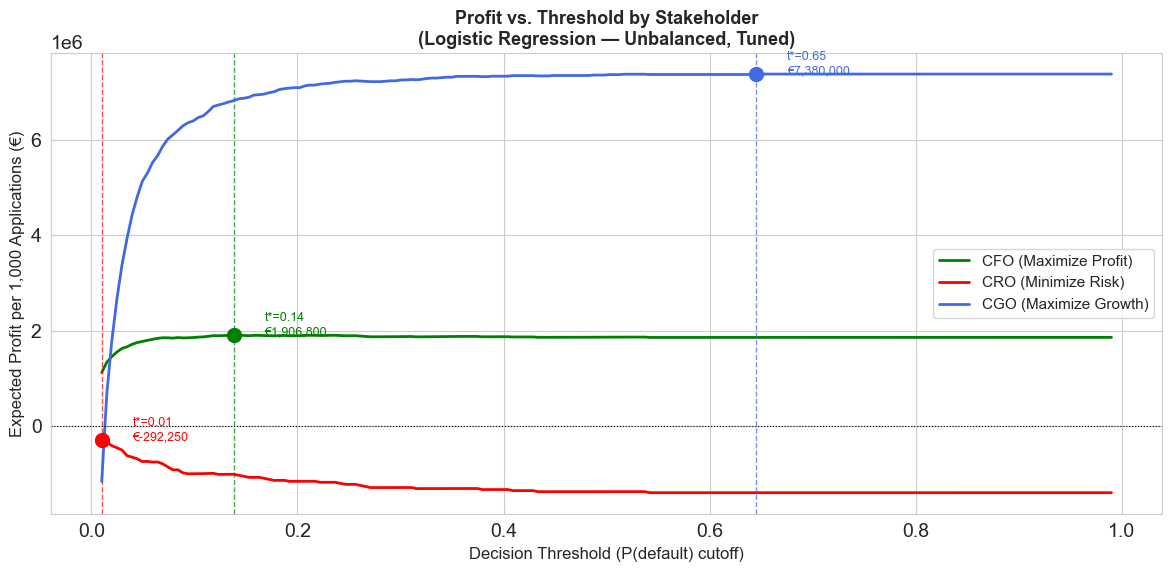

In [21]:
# Profit vs. threshold plot for all three stakeholders
fig, ax = plt.subplots(figsize=(12, 6))
colors_map = {'CFO': 'green', 'CRO': 'red', 'CGO': 'royalblue'}

for key, profits in sweep_results.items():
    ax.plot(thresholds, profits, color=colors_map[key], lw=2, label=f'{key} ({stakeholders[key]["goal"]})')
    o = optimal[key]
    ax.axvline(o['threshold'], color=colors_map[key], ls='--', lw=1, alpha=0.7)
    ax.scatter([o['threshold']], [o['profit_1000']], color=colors_map[key], s=100, zorder=5)
    ax.annotate(f"t*={o['threshold']:.2f}\n€{o['profit_1000']:,.0f}",
                xy=(o['threshold'], o['profit_1000']),
                xytext=(o['threshold'] + 0.03, o['profit_1000']),
                fontsize=9, color=colors_map[key])

ax.axhline(0, color='black', lw=0.8, ls=':')
ax.set_xlabel('Decision Threshold (P(default) cutoff)', fontsize=12)
ax.set_ylabel('Expected Profit per 1,000 Applications (€)', fontsize=12)
ax.set_title('Profit vs. Threshold by Stakeholder\n(Logistic Regression — Unbalanced, Tuned)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('plots/profit_vs_threshold.png', dpi=120, bbox_inches='tight')
plt.show()


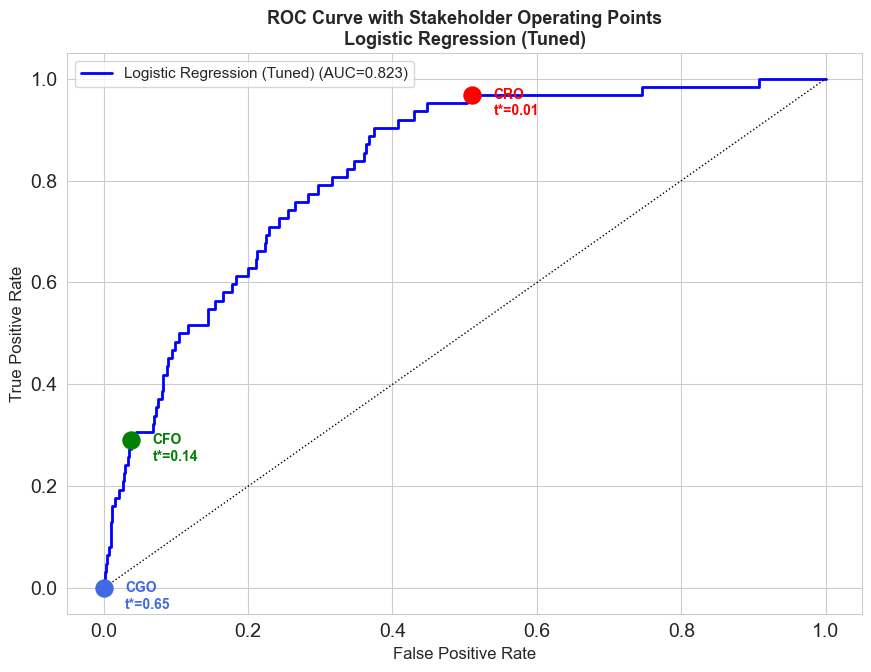

In [22]:
# ROC curve with stakeholder operating points
fpr_best, tpr_best, roc_thresholds = roc_curve(y_test, best_probs)
auc_best = roc_auc_score(y_test, best_probs)

fig, ax = plt.subplots(figsize=(9, 7))
ax.plot(fpr_best, tpr_best, 'b-', lw=2, label=f'{best_model_name} (AUC={auc_best:.3f})')
ax.plot([0, 1], [0, 1], 'k:', lw=1)

for key, o in optimal.items():
    fpr_pt = 1 - o['specificity']
    tpr_pt = o['sensitivity']
    ax.scatter([fpr_pt], [tpr_pt], s=150, zorder=5, color=colors_map[key])
    ax.annotate(f"{key}\nt*={o['threshold']:.2f}",
                xy=(fpr_pt, tpr_pt), xytext=(fpr_pt + 0.03, tpr_pt - 0.04),
                fontsize=10, color=colors_map[key], fontweight='bold')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC Curve with Stakeholder Operating Points\n{best_model_name}', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('plots/roc_operating_points.png', dpi=120, bbox_inches='tight')
plt.show()


## 11. Stakeholder Tradeoff Analysis

For each stakeholder's preferred threshold, we evaluate the payoff from **every** stakeholder's perspective. This produces a 3×3 tradeoff matrix that quantifies the exact cost of satisfying one executive at the expense of another.

We then highlight the key tradeoff statements the CEO needs to hear:
- *"Adopting the CRO's threshold costs the CFO €X per 1,000 applications compared to the CFO's own optimum."*
- *"Adopting the CGO's threshold exposes the CRO to €X in additional regulatory costs."*
- How approval rates shift across strategies.

In [23]:
# ---- Tradeoff table: each stakeholder's payoff under each strategy ----
rows = []
for strategy_key, o in optimal.items():
    y_pred = predict_with_threshold(best_probs, o['threshold'])
    row = {'Strategy': f"{strategy_key} (t={o['threshold']:.2f})"}
    for eval_key, s in stakeholders.items():
        row[f'{eval_key} profit/1k'] = calculate_profit_per_1000(y_test, y_pred, s)
    row['Approval Rate'] = o['approval_rate']
    row['Sensitivity'] = o['sensitivity']
    row['Specificity'] = o['specificity']
    rows.append(row)

tradeoff_df = pd.DataFrame(rows).set_index('Strategy')

print("=" * 90)
print("STAKEHOLDER TRADEOFF TABLE (Expected € per 1,000 Applications)")
print("=" * 90)
print(f"\n{'Strategy':<20} {'CFO €/1k':>12} {'CRO €/1k':>12} {'CGO €/1k':>12} {'Approval%':>10} {'Sensitivity':>12} {'Specificity':>12}")
print("-" * 90)
for idx, row in tradeoff_df.iterrows():
    print(f"{idx:<20} {row['CFO profit/1k']:>12,.0f} {row['CRO profit/1k']:>12,.0f} "
          f"{row['CGO profit/1k']:>12,.0f} {row['Approval Rate']:>10.1%} "
          f"{row['Sensitivity']:>12.3f} {row['Specificity']:>12.3f}")
print("=" * 90)

# ---- Key pairwise tradeoffs ----
cfo_at_cfo = tradeoff_df.loc[f"CFO (t={optimal['CFO']['threshold']:.2f})", 'CFO profit/1k']
cfo_at_cro = tradeoff_df.loc[f"CRO (t={optimal['CRO']['threshold']:.2f})", 'CFO profit/1k']
cfo_at_cgo = tradeoff_df.loc[f"CGO (t={optimal['CGO']['threshold']:.2f})", 'CFO profit/1k']

cro_at_cfo = tradeoff_df.loc[f"CFO (t={optimal['CFO']['threshold']:.2f})", 'CRO profit/1k']
cro_at_cro = tradeoff_df.loc[f"CRO (t={optimal['CRO']['threshold']:.2f})", 'CRO profit/1k']
cro_at_cgo = tradeoff_df.loc[f"CGO (t={optimal['CGO']['threshold']:.2f})", 'CRO profit/1k']

cgo_at_cfo = tradeoff_df.loc[f"CFO (t={optimal['CFO']['threshold']:.2f})", 'CGO profit/1k']
cgo_at_cro = tradeoff_df.loc[f"CRO (t={optimal['CRO']['threshold']:.2f})", 'CGO profit/1k']
cgo_at_cgo = tradeoff_df.loc[f"CGO (t={optimal['CGO']['threshold']:.2f})", 'CGO profit/1k']

print("\n" + "=" * 90)
print("KEY TRADEOFF STATEMENTS")
print("=" * 90)

print(f"""
1. CRO vs. CFO:
   Adopting the CRO's conservative threshold costs the CFO
   €{cfo_at_cfo - cfo_at_cro:,.0f} per 1,000 applications (from €{cfo_at_cfo:,.0f} to €{cfo_at_cro:,.0f}).
   In return, the CRO's risk exposure improves by
   €{cro_at_cro - cro_at_cfo:,.0f}/1k (from €{cro_at_cfo:,.0f} to €{cro_at_cro:,.0f}).
   Approval rate drops from {optimal['CFO']['approval_rate']:.1%} to {optimal['CRO']['approval_rate']:.1%}.

2. CGO vs. CFO:
   Adopting the CGO's aggressive threshold costs the CFO
   €{cfo_at_cfo - cfo_at_cgo:,.0f} per 1,000 applications (from €{cfo_at_cfo:,.0f} to €{cfo_at_cgo:,.0f}).
   The CGO gains €{cgo_at_cgo - cgo_at_cfo:,.0f}/1k in growth value
   (from €{cgo_at_cfo:,.0f} to €{cgo_at_cgo:,.0f}).
   Approval rate rises from {optimal['CFO']['approval_rate']:.1%} to {optimal['CGO']['approval_rate']:.1%}.

3. CGO vs. CRO (the extremes):
   Moving from the CRO's threshold to the CGO's threshold increases
   the CRO's risk exposure by €{cro_at_cgo - cro_at_cro:,.0f}/1k — this is
   the maximum regulatory cost swing across the feasible range.
""")


STAKEHOLDER TRADEOFF TABLE (Expected € per 1,000 Applications)

Strategy                 CFO €/1k     CRO €/1k     CGO €/1k  Approval%  Sensitivity  Specificity
------------------------------------------------------------------------------------------
CFO (t=0.14)            1,906,800   -1,008,500    6,822,000      95.4%        0.290        0.962
CRO (t=0.01)            1,123,800     -292,250   -1,161,000      47.5%        0.968        0.490
CGO (t=0.65)            1,860,600   -1,395,000    7,380,000     100.0%        0.000        1.000

KEY TRADEOFF STATEMENTS

1. CRO vs. CFO:
   Adopting the CRO's conservative threshold costs the CFO
   €783,000 per 1,000 applications (from €1,906,800 to €1,123,800).
   In return, the CRO's risk exposure improves by
   €716,250/1k (from €-1,008,500 to €-292,250).
   Approval rate drops from 95.4% to 47.5%.

2. CGO vs. CFO:
   Adopting the CGO's aggressive threshold costs the CFO
   €46,200 per 1,000 applications (from €1,906,800 to €1,860,600).
   Th

## 12. CEO Decision Framework

Our job is **not** to tell the CEO which executive to side with — that is a strategic and political decision above our pay grade. Our job is to give the CEO the information needed to make that decision well.

This section provides:
1. **The feasible range of thresholds** — from the CRO's conservative extreme to the CGO's aggressive extreme — showing how profit, risk exposure, and approval rate change across the range
2. **Where the "cheap" compromises are** — small moves from the CFO's optimum toward the CRO's threshold that cost very little profit but substantially reduce regulatory exposure
3. **Model interpretability** — the Logistic Regression odds ratios reveal what drives default risk, which helps the CEO assess whose concerns carry more weight
4. **What to monitor after deployment** — actual default rates, threshold recalibration triggers, and sensitivity to changing cost assumptions



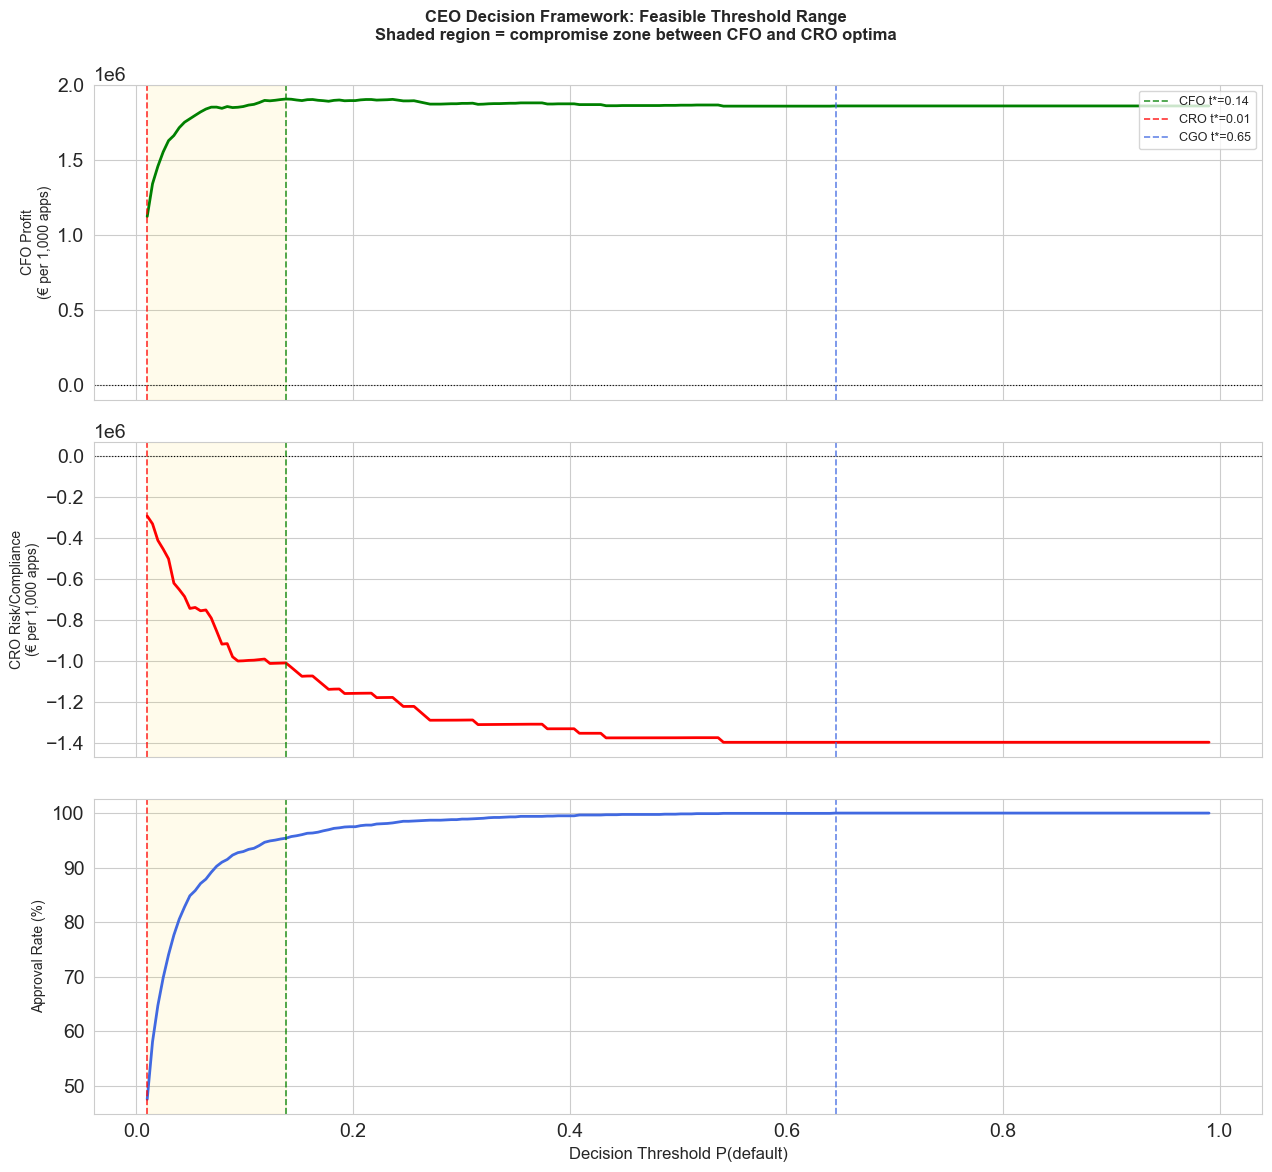

WHERE ARE THE CHEAP COMPROMISES?
Moving from CFO's optimum toward CRO's threshold

 Threshold    CFO €/1k    CRO €/1k    CGO €/1k Approval%    CFO cost    CRO gain
------------------------------------------------------------------------------------------
     0.010    1,123,800     -292,250   -1,161,000      47.6%     -783,000     +716,250 <- CRO
     0.028    1,604,100     -506,250    3,195,000      73.0%     -302,700     +502,250
     0.047    1,761,900     -682,750    4,881,000      83.2%     -144,900     +325,750
     0.065    1,844,700     -749,250    5,703,000      88.1%      -62,100     +259,250
     0.083    1,855,500     -914,500    6,186,000      91.5%      -51,300      +94,000
     0.101    1,862,700     -996,750    6,441,000      93.2%      -44,100      +11,750
     0.120    1,899,900     -989,000    6,720,000      94.8%       -6,900      +19,500
     0.138    1,906,800   -1,008,500    6,822,000      95.4%           +0           +0 <- CFO

Read: 'CFO cost' = profit the CFO 

In [24]:
# ---- CEO Decision Framework ----

# ============================================================
# PART 1: Feasible Threshold Range — Profit, Risk, Approval Rate
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)

axes[0].plot(thresholds, sweep_results['CFO'], color='green', lw=2)
axes[0].set_ylabel('CFO Profit\n(€ per 1,000 apps)', fontsize=10)
axes[0].axhline(0, color='black', lw=0.8, ls=':')

axes[1].plot(thresholds, sweep_results['CRO'], color='red', lw=2)
axes[1].set_ylabel('CRO Risk/Compliance\n(€ per 1,000 apps)', fontsize=10)
axes[1].axhline(0, color='black', lw=0.8, ls=':')

axes[2].plot(thresholds, [r * 100 for r in approval_rates], color='royalblue', lw=2)
axes[2].set_ylabel('Approval Rate (%)', fontsize=10)
axes[2].set_xlabel('Decision Threshold P(default)', fontsize=12)

for key, o in optimal.items():
    for ax in axes:
        ax.axvline(o['threshold'], color=colors_map[key], ls='--', lw=1.2, alpha=0.8,
                   label=f"{key} t*={o['threshold']:.2f}")

axes[0].legend(fontsize=9, loc='upper right')

# Shade compromise zone between CRO and CFO
t_cro = optimal['CRO']['threshold']
t_cfo = optimal['CFO']['threshold']
t_lo, t_hi = min(t_cro, t_cfo), max(t_cro, t_cfo)
for ax in axes:
    ax.axvspan(t_lo, t_hi, alpha=0.08, color='gold')

fig.suptitle('CEO Decision Framework: Feasible Threshold Range\n'
             'Shaded region = compromise zone between CFO and CRO optima',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/ceo_framework.png', dpi=120, bbox_inches='tight')
plt.show()

# ============================================================
# PART 2: "Cheap Compromises" — marginal cost of moving toward CRO
# ============================================================
print("=" * 90)
print("WHERE ARE THE CHEAP COMPROMISES?")
print("Moving from CFO\'s optimum toward CRO\'s threshold")
print("=" * 90)

compromise_thresholds = np.linspace(t_lo, t_hi, 8)
header_comp = "Threshold".rjust(10) + "CFO €/1k".rjust(12) + "CRO €/1k".rjust(12) + "CGO €/1k".rjust(12) + "Approval%".rjust(10) + "CFO cost".rjust(12) + "CRO gain".rjust(12)
print("\n" + header_comp)
print("-" * 90)

y_pred_cfo_base = predict_with_threshold(best_probs, optimal['CFO']['threshold'])
cfo_base = calculate_profit_per_1000(y_test, y_pred_cfo_base, stakeholders['CFO'])
cro_base = calculate_profit_per_1000(y_test, y_pred_cfo_base, stakeholders['CRO'])

for t in compromise_thresholds:
    y_pred_t = predict_with_threshold(best_probs, t)
    appr = 1 - y_pred_t.mean()
    cfo_val = calculate_profit_per_1000(y_test, y_pred_t, stakeholders['CFO'])
    cro_val = calculate_profit_per_1000(y_test, y_pred_t, stakeholders['CRO'])
    cgo_val = calculate_profit_per_1000(y_test, y_pred_t, stakeholders['CGO'])
    marker = ""
    if abs(t - optimal['CFO']['threshold']) < 0.01:
        marker = " <- CFO"
    elif abs(t - optimal['CRO']['threshold']) < 0.01:
        marker = " <- CRO"
    print(f"{t:>10.3f} {cfo_val:>12,.0f} {cro_val:>12,.0f} {cgo_val:>12,.0f} {appr:>10.1%} "
          f"{cfo_val - cfo_base:>+12,.0f} {cro_val - cro_base:>+12,.0f}{marker}")

print("=" * 90)
print("\nRead: \'CFO cost\' = profit the CFO gives up vs. their optimum.")
print("      \'CRO gain\' = risk reduction the CRO gains vs. CFO\'s threshold.")
print("      Look for rows where CRO gain is large but CFO cost is small.")

# ============================================================
# PART 3: Summary Table for the CEO
# ============================================================
print("\n\n" + "=" * 90)
print("SUMMARY TABLE FOR THE CEO")
print("=" * 90)
header_sum = "Strategy".ljust(20) + "Threshold".rjust(10) + "Approval%".rjust(10) + "CFO €/1k".rjust(12) + "CRO €/1k".rjust(12) + "CGO €/1k".rjust(12)
print("\n" + header_sum)
print("-" * 90)
for strategy_key, o in optimal.items():
    y_pred = predict_with_threshold(best_probs, o['threshold'])
    row_vals = {k: calculate_profit_per_1000(y_test, y_pred, s) for k, s in stakeholders.items()}
    label = f"{strategy_key} optimal"
    print(f"{label:<20} {o['threshold']:>10.3f} {o['approval_rate']:>10.1%} "
          f"{row_vals['CFO']:>12,.0f} {row_vals['CRO']:>12,.0f} {row_vals['CGO']:>12,.0f}")
print("=" * 90)

# ============================================================
# PART 4: Post-Deployment Monitoring
# ============================================================
print("""
POST-DEPLOYMENT MONITORING — WHAT TO KEEP IN MIND
============================================================

1. ACTUAL DEFAULT RATES
   After deployment, the bank should track the actual default rate
   among approved loans and compare it against the ~3% base rate
   observed in the training data. If the realized default rate
   deviates noticeably from this baseline, it means the population
   of applicants or the economic environment has changed, and the
   model's probability estimates — and therefore the optimal
   thresholds — may no longer be accurate.

2. WHEN TO RECALIBRATE
   Recalibration of the threshold should be considered whenever:
   - The realized default rate shifts materially from the training
     baseline (~3%)
   - The cost structure used in the profit calculation is updated
     (see point 3 below)
   - A significant macroeconomic event (e.g. a recession or a
     policy change) alters the lending environment
   In each case, the profit-per-1,000 sweep should be re-run with
   updated data or updated costs to find the new optimal operating
   point for each stakeholder.

3. SENSITIVITY TO COST CHANGES
   The optimal thresholds we derived depend directly on the costs
   assigned to each outcome (TN, FP, FN, TP) for every stakeholder.
   If those costs change — for example, if regulatory penalties for
   missed defaults increase (raising the CRO's FN cost), the optimal
   threshold shifts lower, leading to more rejections and fewer
   missed defaults. Conversely, if the value of acquiring good
   customers grows (raising the CGO's TN value), the threshold shifts
   higher, leading to more approvals. The threshold is therefore not
   a fixed number but a policy lever that should be re-optimized
   whenever the underlying cost assumptions are revised.
""")
